<a href="https://colab.research.google.com/github/isambilo/rML/blob/main/ASSN02_COMPAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open the methodology in another tab to understand the following.

---
# Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Importing all required libraries
import warnings
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

# Number of rows
raw_data.shape[0]

7214

In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:

* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
# --- Variable groups ---------------------------------------------------------
numeric_vars  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# --- Column selection --------------------------------------------------------
df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat",
        "score_text", "sex", "priors_count",
        "days_b_screening_arrest", "decile_score", "is_recid",
        "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# --- Filtering ---------------------------------------------------------------
df = df[
    (df["days_b_screening_arrest"].between(-30, 30))
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"] != "N/A")
]

# --- Type conversions --------------------------------------------------------
# Convert datetime columns
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric, non-datetime columns to category
for col in df.columns:
  if col not in numeric_vars + datetime_vars:
    df[col] = df[col].astype("category")

# --- Derived categorical variables ------------------------------------------
df["crime_factor"] = df["c_charge_degree"].astype("category")

# Relevel age_cat with "25 - 45" as reference
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].unique() if c != "25 - 45"],
    ordered = False
    )

# Relevel race with "Caucasian" as reference
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].unique() if c != "Caucasian"])

# gender_factor with labels Female/Male and reference
df["gender_factor"] = df["sex"].map({
    "Female" : "Female",
    "Male" : "Male"
}).astype("category")

df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"], # reference first
    ordered=False
)

# Score factor: LowScore vs HighScore
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"],
    ordered=False
)


# --- Row count ---------------------------------------------------------------
df.shape[0]

6172

In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
# Length of stay (in days)
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
    ).dt.days

# Correlation
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.2073296916147046)

After filtering we have the following demographic breakdown:

In [8]:
df["age_cat"].value_counts().to_frame().T

age_cat,25 - 45,Less than 25,Greater than 45
count,3532,1347,1293


In [9]:
df["race"].value_counts().to_frame().T

race,African-American,Caucasian,Hispanic,Other,Asian,Native American
count,3175,2103,509,343,31,11


In [10]:
# Compute Proportions
race_dist = df["race"].value_counts(normalize=True) * 100

# Print in desire format
for race, pct in race_dist.items():
  print(f"{race} defendants: {pct:.2f}%")

African-American defendants: 51.44%
Caucasian defendants: 34.07%
Hispanic defendants: 8.25%
Other defendants: 5.56%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
df["score_text"].value_counts().to_frame().T

score_text,Low,Medium,High
count,3421,1607,1144


In [12]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
df["sex"].value_counts().to_frame().T

sex,Male,Female
count,4997,1175


In [14]:
# Compute Proportions
sex_dist = df["sex"].value_counts(normalize=True) * 100

# Print in desired format
for sex, pct in sex_dist.items():
  print(f"{sex} defendants: {pct:.2f}%")

Male defendants: 80.96%
Female defendants: 19.04%


In [15]:
df[df["two_year_recid"] == 1].shape[0]

2809

In [16]:
(df["two_year_recid"] == 1).mean() * 100

np.float64(45.51198963058976)

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

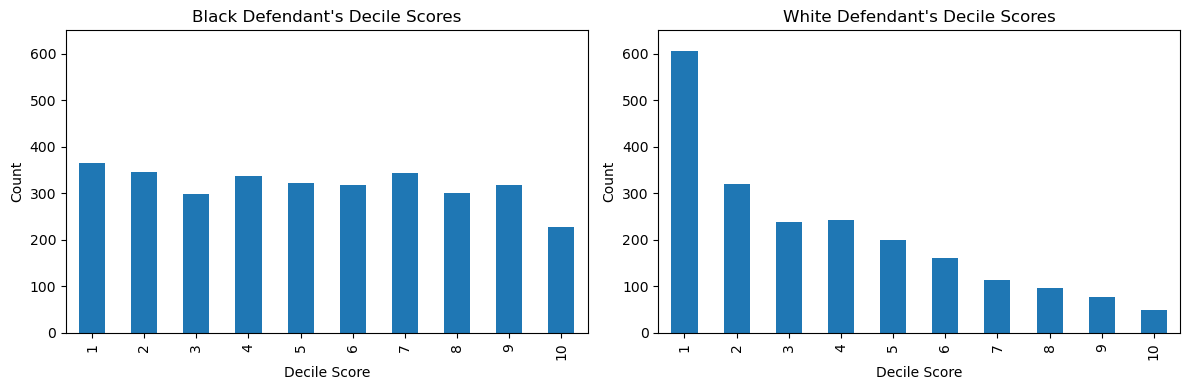

In [17]:
import matplotlib.pyplot as plt
# Filter data
df_black = df[df["race"] == "African-American"]
df_white = df[df["race"] == "Caucasian"]
# Create figure
plt.figure(figsize=(12, 4))
# --- Black defendants ---
plt.subplot(1, 2, 1)
df_black["decile_score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.title("Black Defendant's Decile Scores")
plt.ylim(0, 650)
# --- White defendants ---
plt.subplot(1, 2, 2)
df_white["decile_score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.title("White Defendant's Decile Scores")
plt.ylim(0, 650)
plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [19]:
pd.crosstab(df["decile_score"], df["score_factor"])

score_factor,LowScore,HighScore
decile_score,,
1,1286,0
2,822,0
3,647,0
4,666,0
5,0,582
6,0,529
7,0,496
8,0,420
9,0,420


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. Because we've already changed some variables into category type, we'll now run a logistic regression, comparing low scores to high scores.

In [20]:
import statsmodels.formula.api as smf

# Make binary outcome
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Fit logistic regression
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor) +
    C(age_factor) +
    C(race_factor) +
    priors_count +
    C(crime_factor) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        02:15:52   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

Compare Black defendants with White defendants after correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [21]:
beta_0 = model_glm.params["Intercept"]
beta_race = model_glm.params["C(race_factor)[T.African-American]"]
p_control = 1 / (1 + np.exp(-beta_0))
p_group = 1 / (1 + np.exp(-(beta_0 + beta_race)))
ratio = p_group / p_control
ratio

np.float64(1.4528374133823447)

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [22]:
beta_sex = model_glm.params["C(gender_factor)[T.Female]"]
p_group = 1 / (1 + np.exp(-(beta_0 + beta_sex)))
ratio = p_group / p_control
ratio

np.float64(1.1947946538834513)

Women are 19.4% more likely than men to get a higher score.

In [23]:
beta_sex = model_glm.params["C(age_factor)[T.Less than 25]"]
p_group = 1 / (1 + np.exp(-(beta_0 + beta_sex)))
ratio = p_group / p_control
ratio

np.float64(2.496119530753956)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

Confusion Matrix Building Workflow:

In [24]:
# Predicted probabilities
df["pred_prob"] = model_glm.predict(df)
# Predicted class (threshold = 0.5)
df["pred_class"] = (
    (df["pred_prob"] >= 0.5)
    .map({False: "No Recid", True: "Recid"})
    .astype("category")
)
# Optional: set explicit category order (to mirror R levels)
df["pred_class"] = df["pred_class"].cat.set_categories(["No Recid", "Recid"])

In [25]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

# Confusion matrix
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

# Extract values (same layout as R)
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

# Metrics
accuracy  = (TP + TN) / n
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
fpr       = FP / (FP + TN)
fnr       = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [26]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

# Create actual and predicted numeric columns
df_metrics = df.copy()
df_metrics["actual"] = df_metrics["two_year_recid"].astype(int)
df_metrics["pred"] = (df_metrics["pred_class"] == "Recid").astype(int)

# Group by race and compute metrics
race_metrics = (
    df_metrics
    .groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

# Compute metrics
race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by descending n
race_metrics = race_metrics.sort_values(by="n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


FPR and FNR Disparity by Race.

In [27]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

# Select relevant columns
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get baseline (Caucasian)
baseline_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
baseline_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute disparities
disparity["delta_FPR"] = (disparity["FPR"] - baseline_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - baseline_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


---
# **START ASSIGNMENT 2**

## Explaining the COMPAS Replacement Model

For the next analysis, the same features and target variables from the logistic function will be used.

Let's begin with creating our Train and Test sets.

Loading Required Libraries

In [28]:
%pip install lime # install if necessary
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (confusion_matrix, accuracy_score,roc_auc_score)
from lime.lime_tabular import LimeTabularExplainer

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.


In [29]:
# Use the same feature set as the logistic regression model
features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid",
]

# Binary target from the earlier setup
target = "score_binary"

# Build X and y
X = df[features].copy()
y = df[target].astype(int).copy()

# Train/test split with stratification on the target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Compute counts
n_total = len(X)
n_train = len(X_train)
n_test = len(X_test)

# Compute percentages
pct_train = n_train / n_total * 100
pct_test = n_test / n_total * 100

print(
    f"Train: {X_train.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

Train: (4937, 6) (4,937 rows, 80.0%), Test: (1235, 6) (1,235 rows, 20.0%)


Fitting logistic regression and gradient-boosted tree

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define feature groups (aligned with Lecture 01 / earlier pipeline)
numeric_features = ["priors_count", "two_year_recid"]
categorical_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Logistic Regression (interpretable model)
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)

# Gradient Boosted Trees (black-box model)
gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )),
])

gbt_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Compare model performance by race.

In [31]:
def group_metrics(pipeline, X, y, group_col="race_factor"):
  results = []
  X_ = X.copy()
  X_["actual"] = y.values
  X_["pred"] = pipeline.predict(X)
  X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

  for group, gdf in X_.groupby(group_col):
    # Ensure full 2x2 matrix even if a class is missing
    tn, fp, fn, tp = confusion_matrix(
        gdf["actual"], gdf["pred"], labels=[0,1]
        ).ravel()

    # Safe division
    def safe_div(num, den):
      return num / den if den != 0 else np.nan

    results.append({
        "race" : group,
        "n" : len(gdf),
        "accuracy" : round(accuracy_score(
            gdf["actual"], gdf["pred"]), 3),
        "FPR" : round(safe_div(fp, (fp + tn)), 3),
        "FNR" : round(safe_div(fn, (fn + tp)), 3),
        "AUC" : round(
            roc_auc_score(
            gdf["actual"],
            gdf["pred_prob"])
            if gdf["actual"].nunique() > 1 else np.nan, 3),
        })
  return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
1             Other   71     0.803  0.019  0.765  0.852
4             Asian    8     0.750  0.000  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
1             Other   71     0.845  0.019  0.588  0.846
4             Asian    8     0.625  0.167  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000


LIME explanations: Black vs White defendant

In [32]:
%pip install lime

from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Use the fitted preprocessor and classifier from the trained GBT pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Encode training data using the fitted preprocessor
X_train_enc = fitted_preprocessor.transform(X_train)

# Feature names after preprocessing
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feature_names = numeric_features + cat_feature_names

# Build LIME explainer on encoded training data
X_train_enc_array = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc

explainer = LimeTabularExplainer(
    training_data=X_train_enc_array,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

# Predict probabilities on raw test data using the full pipeline
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

# Copy raw test data for selection
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Select median-risk Black and White defendants
black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")

black_idx = black_df.index[len(black_df) // 2]
white_idx = white_df.index[len(white_df) // 2]

# Generate LIME explanations
for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    row_raw = X_test.loc[[idx]]
    row_enc = fitted_preprocessor.transform(row_raw)
    row_enc_array = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc[0]

    exp = explainer.explain_instance(
        data_row=row_enc_array,
        predict_fn=fitted_classifier.predict_proba,
        num_features=6,
    )

    print(f"\nLIME: {label}")
    print(f"Predicted probability: {gbt_pipeline.predict_proba(row_raw)[0, 1]:.3f}")

    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")

Note: you may need to restart the kernel to use updated packages.

LIME: Black defendant
Predicted probability: 0.594
 age_factor_Less than 25 <= 0.00          -0.3533
 age_factor_Greater than 45 <= 0.00       +0.2270
 -0.92 < two_year_recid <= 1.09           +0.0943
 0.00 < race_factor_African-American <= 1.00 +0.0934
 -0.47 < priors_count <= 0.17             -0.0904
 race_factor_Hispanic <= 0.00             +0.0903

LIME: White defendant
Predicted probability: 0.241
 race_factor_Native American <= 0.00      -0.4254
 age_factor_Less than 25 <= 0.00          -0.3535
 -0.68 < priors_count <= -0.47            -0.2692
 age_factor_Greater than 45 <= 0.00       +0.2236
 race_factor_African-American <= 0.00     -0.1046
 two_year_recid <= -0.92                  -0.0872


SHAP beeswarm and waterfall: Black vs White

Note: you may need to restart the kernel to use updated packages.


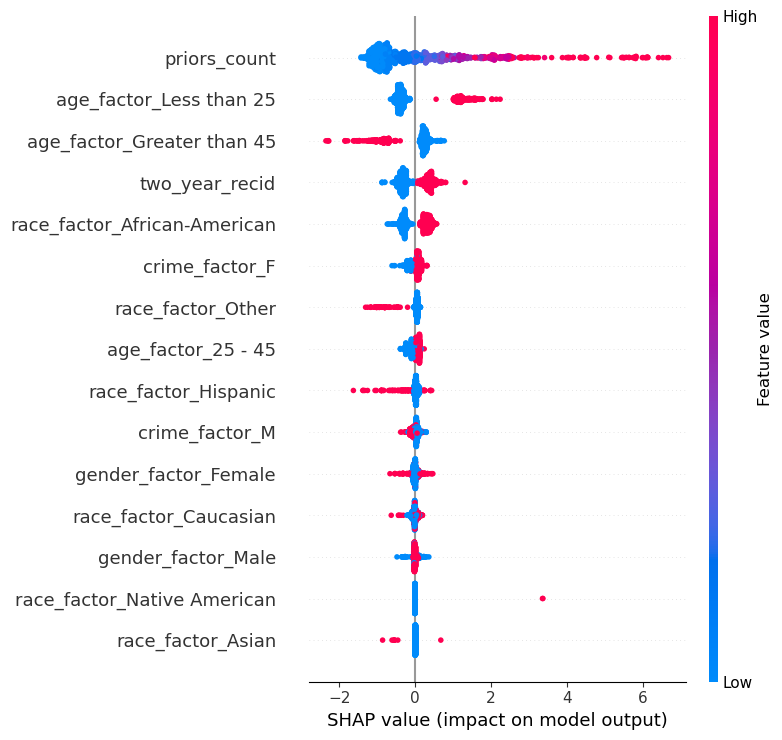

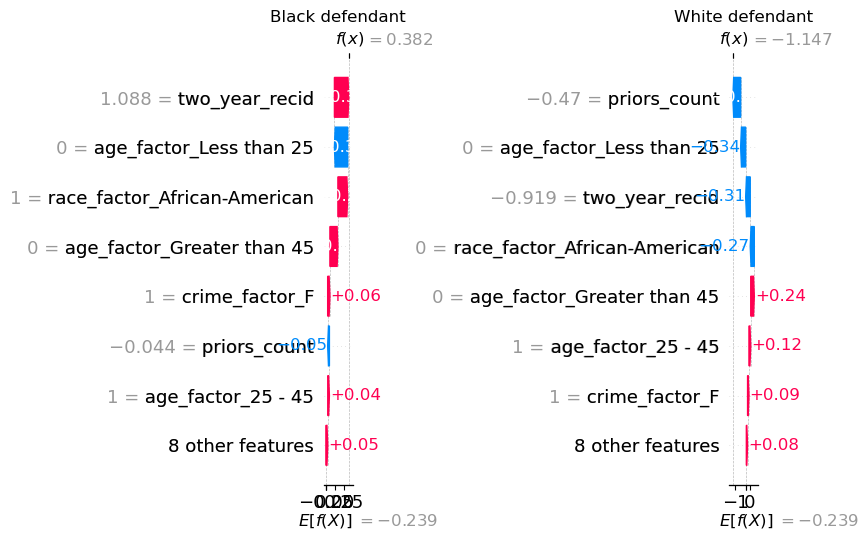

In [33]:
%pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np

# Use the fitted components from the trained GBT pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Encode test data with the fitted preprocessor
X_test_enc = fitted_preprocessor.transform(X_test)
X_test_enc_array = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

# Feature names after preprocessing
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feat_names = numeric_features + cat_feature_names

# SHAP explainer for tree model
explainer_shap = shap.TreeExplainer(fitted_classifier)
shap_values = explainer_shap.shap_values(X_test_enc_array)

# Global summary plot
shap.summary_plot(
    shap_values,
    X_test_enc_array,
    feature_names=feat_names,
    show=False
)
plt.tight_layout()
plt.show()

# Waterfall plots for selected Black and White defendants
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

expected_value = explainer_shap.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    if np.ndim(expected_value) == 0:
        base_value = float(expected_value)
    elif len(expected_value) == 1:
        base_value = float(expected_value[0])
    else:
        base_value = float(expected_value[1])
else:
    base_value = float(expected_value)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant"),
]:
    plt.sca(ax)

    explanation = shap.Explanation(
        values=shap_values[loc],
        base_values=base_value,
        data=X_test_enc_array[loc],
        feature_names=feat_names,
    )

    shap.waterfall_plot(
        explanation,
        max_display=8,
        show=False
    )
    ax.set_title(label)

plt.tight_layout()
plt.show()

Counterfactuals with DiCE: Black vs White

In [34]:
%pip install dice-ml

import dice_ml
from dice_ml import Dice
import pandas as pd

# Build training dataframe
train_df = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)],
    axis=1
).copy()

# Ensure continuous features are truly numeric for DiCE
for col in numeric_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

# Ensure target is numeric
train_df[target] = pd.to_numeric(train_df[target], errors="coerce").astype(int)

# Optional sanity check
print(train_df[numeric_features + [target]].dtypes)

# Create DiCE data interface
dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numeric_features,
    outcome_name=target
)

# Wrap the fitted sklearn pipeline
dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

# Initialize DiCE
exp_dice = Dice(dice_data, dice_model, method="random")

# Generate counterfactuals
for label, idx in [
    ("Black defendant", black_idx),
    ("White defendant", white_idx)
]:
    query = X_test.loc[[idx]].copy()

    # Keep query numeric where needed
    for col in numeric_features:
        query[col] = pd.to_numeric(query[col], errors="coerce")

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "priors_count": [0, 38],
            "two_year_recid": [0, 1],
        },
        features_to_vary=[
            "priors_count",
            "two_year_recid",
            "crime_factor",
        ]
    )

    print(f"\nDiCE counterfactuals: {label}")
    display(cf.visualize_as_dataframe(show_only_changes=True))

Note: you may need to restart the kernel to use updated packages.
priors_count      int64
two_year_recid    int64
score_binary      int64
dtype: object


100%|██████████| 1/1 [00:00<00:00,  8.34it/s]


DiCE counterfactuals: Black defendant
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,African-American,3,F,1,1



Diverse Counterfactual set (new outcome: 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,-,M,0,0
1,-,-,-,0,-,0,0
2,-,-,-,-,-,0,0


None

100%|██████████| 1/1 [00:00<00:00,  9.97it/s]


DiCE counterfactuals: White defendant
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Caucasian,1,F,0,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,37,-,-,1
1,-,-,-,38,-,1,1
2,-,-,-,21,-,-,1


None

**Governance memo on COMPAS model explanations**

This memo summarizes findings from SHAP, LIME, and DiCE analyses of the COMPAS replacement model looking at transparency, fairness, and how well it works in court settings. Across all methods, the model shows strong dependence on three factors: `priors_count`, `age_factor`, and `two_year_recid`. SHAP results indicate that younger defendants, particularly those in the “Less than 25” group, receive substantially higher risk contributions, while older defendants receive strong negative contributions. Waterfall plots for the highest‑ and lowest‑risk individuals in each racial group show that Black defendants often accumulate larger positive contributions from age and priors than White defendants with similar profiles, showing disparities observed in false‑positive and false‑negative rates.

LIME explanations for the same individuals generally agree with SHAP on the importance of priors and age but display greater variability in feature weighting. This instability reflects LIME’s sensitivity to local perturbations and highlights the governance risk of relying on a single explanation method. Divergence between SHAP and LIME underligns the need for multi‑method oversight to avoid over‑interpreting any one explanation.

DiCE counterfactuals were generated for each individual to identify the minimal changes required to flip predictions. The model groups age into categories, so counterfactuals can only show changes between those brackets, not small, gradual age shifts. Most of the counterfactual scenarios involved lowering `priors_count` or moving into a higher age group. It tends to favor older brackets when trying to reduce risk scores. None required changes to immutable features such as race or sex, consistent with ethical constraints.

Monitoring should happen regularly with checks on racial differences in error rates, stability comparisons between SHAP and LIME explanations, and repeated counterfactual testing after any update. A governance process combining statistical fairness measures with explanation-based diagnostics is probably best for maintaining transparency, stability, and compliance with judicial fairness norms. This approach helps keep the model aligned with real-world outcomes over time.


---
# **START ASSIGNMENT 3**

Setup and imports

In [35]:
%pip install solas-ai
import solas_disparity as sd

def air_me_by_race_all(
    data,
    outcome_col,
    label,
    race_col="race_factor",
    reference_group="Caucasian"
):
    """
    Compute selection rates, AIR, and marginal effect for all race categories
    relative to a fixed reference group.

    Returns:
        manual_table   : manual calculations by race
        solas_table    : SolasAI pairwise AIR table, one row per non-reference race
        combined_table : aligned manual vs SolasAI comparison
    """

    # Prepare data
    work = data[[race_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Manual calculations
    manual_table = (
        work.groupby(race_col, dropna=False)[outcome_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            race_col: "race",
            "count": "n_manual",
            "sum": "favorable_manual",
            "mean": "selection_rate_manual"
        })
    )

    if reference_group not in manual_table["race"].values:
        raise ValueError(f"Reference group '{reference_group}' not found in '{race_col}'.")

    ref_rate = manual_table.loc[
        manual_table["race"] == reference_group, "selection_rate_manual"
    ].iloc[0]

    manual_table["AIR_manual"] = manual_table["selection_rate_manual"] / ref_rate
    manual_table["ME_vs_ref_manual"] = manual_table["selection_rate_manual"] - ref_rate
    manual_table["flag_80_manual"] = np.where(
        manual_table["AIR_manual"] < 0.80, "*** BELOW 0.80", ""
    )

    manual_table = manual_table.sort_values(
        by=["AIR_manual", "race"],
        ascending=[True, True]
    ).reset_index(drop=True)

    # SolasAI pairwise AIR
    group_data = pd.get_dummies(work[race_col], dtype=int)
    solas_results = []

    for grp in group_data.columns:
        if grp == reference_group:
            continue

        air_obj = sd.adverse_impact_ratio(
            group_data=group_data[[grp, reference_group]],
            protected_groups=[grp],
            reference_groups=[reference_group],
            group_categories=["race"],
            outcome=work[outcome_col],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )

        tbl = air_obj.summary_table.copy().reset_index()

        if "Group" not in tbl.columns:
            if "index" in tbl.columns:
                tbl = tbl.rename(columns={"index": "Group"})
            else:
                tbl = tbl.rename(columns={tbl.columns[0]: "Group"})

        tbl = tbl[tbl["Group"] == grp].copy()

        tbl = tbl.rename(columns={
            "Group": "race",
            "Total": "n_solas",
            "Favorable": "favorable_solas",
            "Percent Favorable": "selection_rate_solas",
            "AIR": "AIR_solas",
            "Percent Difference Favorable": "ME_vs_ref_solas",
            "P-Values": "p_value",
            "Practically Significant": "practically_significant",
            "Shortfall": "shortfall"
        })

        if "selection_rate_solas" in tbl.columns:
            tbl["selection_rate_solas"] = pd.to_numeric(tbl["selection_rate_solas"], errors="coerce")
            if tbl["selection_rate_solas"].max() > 1:
                tbl["selection_rate_solas"] = tbl["selection_rate_solas"] / 100.0

        if "ME_vs_ref_solas" in tbl.columns:
            tbl["ME_vs_ref_solas"] = pd.to_numeric(tbl["ME_vs_ref_solas"], errors="coerce")
            if tbl["ME_vs_ref_solas"].abs().max() > 1:
                tbl["ME_vs_ref_solas"] = tbl["ME_vs_ref_solas"] / 100.0

        solas_results.append(tbl)

    if solas_results:
        solas_table = pd.concat(solas_results, ignore_index=True)
    else:
        solas_table = pd.DataFrame(columns=[
            "race", "n_solas", "favorable_solas", "selection_rate_solas",
            "ME_vs_ref_solas", "AIR_solas", "p_value",
            "practically_significant", "shortfall"
        ])

    # Align ordering
    race_order = manual_table["race"].tolist()

    if not solas_table.empty:
        solas_table["race"] = pd.Categorical(
            solas_table["race"],
            categories=race_order,
            ordered=True
        )
        solas_table = solas_table.sort_values("race").reset_index(drop=True)

    # Combined table
    combined_table = manual_table.merge(
        solas_table,
        on="race",
        how="left"
    )

    # Round only for display cleanliness
    for col in [
        "selection_rate_manual", "AIR_manual", "ME_vs_ref_manual",
        "selection_rate_solas", "AIR_solas", "ME_vs_ref_solas", "p_value"
    ]:
        if col in combined_table.columns:
            combined_table[col] = pd.to_numeric(combined_table[col], errors="coerce").round(4)

    print(f"\n{label}")
    print(combined_table.to_string(index=False))

    return manual_table, solas_table, combined_table

Note: you may need to restart the kernel to use updated packages.


AIR and Marginal Effect by race

In [36]:
# -------------------------------------------------------------------
# (a) RAW DATA: actual COMPAS high-risk outcome by race
# -------------------------------------------------------------------
pd.set_option("display.float_format", "{:.4f}".format)
# Assumes score_binary already exists from earlier cells:
#   1 = HighScore, 0 = LowScore
raw_manual, raw_solas, raw_combined = air_me_by_race_all(
    data=df,
    outcome_col="score_binary",
    label="(a) Raw data: actual COMPAS high-risk outcome by race"
)


(a) Raw data: actual COMPAS high-risk outcome by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing   n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other       343                70                 0.2041      0.6166           -0.1269 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000  343.0000          70.0000                0.2041           0.1269     0.6166   0.0000                     Yes    43.5178
           Asian        31                 7                 0.2258      0.6823           -0.1051 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000   31.0000           7.0000                0.2258           0.1051     0.6823   0.2522                      No        NaN
        Hispanic       509               141             

In [37]:
# -------------------------------------------------------------------
# (b) LOGISTIC REGRESSION: predicted class on TEST data by race
# -------------------------------------------------------------------
lr_eval = X_test.copy()
lr_eval["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_manual, lr_solas, lr_combined = air_me_by_race_all(
    data=lr_eval,
    outcome_col="pred_high_risk",
    label="(b) Logistic regression: predicted high-risk class on test data by race"
)


(b) Logistic regression: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Asian         8                 0                 0.0000      0.0000           -0.2112 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           0.0000                0.0000           0.2112     0.0000   0.2147                      No        NaN
           Other        71                 5                 0.0704      0.3335           -0.1407 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           5.0000                0.0704           0.1407     0.3335   0.0048                     Yes     9.9927
        Hispanic       108                

In [38]:
# -------------------------------------------------------------------
# (c) GBT / xGBoost-style model: predicted class on TEST data by race
# -------------------------------------------------------------------
gbt_eval = X_test.copy()
gbt_eval["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_manual, gbt_solas, gbt_combined = air_me_by_race_all(
    data=gbt_eval,
    outcome_col="pred_high_risk",
    label="(c) Gradient-boosted model: predicted high-risk class on test data by race"
)


(c) Gradient-boosted model: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other        71                 8                 0.1127      0.4887           -0.1179 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           8.0000                0.1127           0.1179     0.4887   0.0274                     Yes     8.3714
           Asian         8                 1                 0.1250      0.5421           -0.1056 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           1.0000                0.1250           0.1056     0.5421   0.6886                      No        NaN
        Hispanic       108             

In [39]:
def error_rates_by_group(data, group_col, pred_col, outcome_col):
    results = []

    for grp, g in data.groupby(group_col, dropna=False):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        n = len(g)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tp + tn) / n if n > 0 else np.nan

        results.append({
            group_col: grp,
            "n": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False).reset_index(drop=True)

In [40]:
# -------------------------------------------------------------------
# Logistic regression: error rates by race on test data
# -------------------------------------------------------------------
lr_err_df = X_test.copy()
lr_err_df["actual"] = y_test.values
lr_err_df["pred"] = lr_pipeline.predict(X_test).astype(int)

lr_error_rates = error_rates_by_group(
    data=lr_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Logistic Regression: Error Rates by Race (Test Data) ===")
print(lr_error_rates.to_string(index=False))


=== Logistic Regression: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 307 160 101  66    0.7370 0.3870 0.1770
       Caucasian 412  56 253  31  72    0.7500 0.1090 0.5620
        Hispanic 108  15  74   5  14    0.8240 0.0630 0.4830
           Other  71   4  53   1  13    0.8030 0.0190 0.7650
           Asian   8   0   6   0   2    0.7500 0.0000 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000


In [41]:
# -------------------------------------------------------------------
# Gradient-boosted model: error rates by race on test data
# -------------------------------------------------------------------
gbt_err_df = X_test.copy()
gbt_err_df["actual"] = y_test.values
gbt_err_df["pred"] = gbt_pipeline.predict(X_test).astype(int)

gbt_error_rates = error_rates_by_group(
    data=gbt_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===")
print(gbt_error_rates.to_string(index=False))


=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 282 167  94  91    0.7080 0.3600 0.2440
       Caucasian 412  67 256  28  61    0.7840 0.0990 0.4770
        Hispanic 108  16  72   7  13    0.8150 0.0890 0.4480
           Other  71   7  53   1  10    0.8450 0.0190 0.5880
           Asian   8   0   5   1   2    0.6250 0.1670 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000


Standardized Mean Difference

In [42]:
def smd_by_group(data, group_col, score_col, ref_group="Caucasian"):
    """
    Compute standardized mean difference (Cohen's d) for each group
    relative to a reference group on a continuous score.
    """
    work = data[[group_col, score_col]].copy()
    work[score_col] = pd.to_numeric(work[score_col], errors="coerce")
    work = work.dropna(subset=[group_col, score_col]).copy()

    if ref_group not in work[group_col].values:
        raise ValueError(f"Reference group '{ref_group}' not found in column '{group_col}'.")

    ref = work.loc[work[group_col] == ref_group, score_col]

    results = []
    for grp, g in work.groupby(group_col, dropna=False):
        if grp == ref_group:
            continue

        sc = g[score_col]

        # Pooled SD
        pooled_sd = np.sqrt((ref.var(ddof=1) + sc.var(ddof=1)) / 2)
        d = ((sc.mean() - ref.mean()) / pooled_sd) if pooled_sd > 0 else np.nan

        # Magnitude by absolute SMD
        ad = abs(d)
        magnitude = (
            "small" if ad < 0.2 else
            "medium" if ad < 0.5 else
            "large" if ad < 0.8 else
            "very large"
        )

        results.append({
            group_col: grp,
            "n_group": len(sc),
            "n_ref": len(ref),
            "mean_score_group": round(sc.mean(), 3),
            "mean_score_ref": round(ref.mean(), 3),
            "SMD": round(d, 3),
            "abs_SMD": round(abs(d), 3),
            "magnitude": magnitude
        })

    return pd.DataFrame(results).sort_values("abs_SMD", ascending=False).reset_index(drop=True)

In [43]:
# -------------------------------------------------------------------
# Logistic regression: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
lr_smd_df = X_test.copy()
lr_smd_df["pred_prob"] = lr_pipeline.predict_proba(X_test)[:, 1]

lr_smd_table = smd_by_group(
    data=lr_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(lr_smd_table.to_string(index=False))


=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.6500          0.3170  1.4910   1.4910 very large
African-American      634    412            0.5880          0.3170  1.0770   1.0770 very large
           Asian        8    412            0.1560          0.3170 -0.8310   0.8310 very large
           Other       71    412            0.2010          0.3170 -0.5320   0.5320      large
        Hispanic      108    412            0.3030          0.3170 -0.0610   0.0610      small


In [44]:
# -------------------------------------------------------------------
# Gradient-boosted model: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
gbt_smd_df = X_test.copy()
gbt_smd_df["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

gbt_smd_table = smd_by_group(
    data=gbt_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(gbt_smd_table.to_string(index=False))


=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.9810          0.3130  3.7130   3.7130 very large
African-American      634    412            0.5840          0.3130  1.0390   1.0390 very large
           Asian        8    412            0.1830          0.3130 -0.4820   0.4820     medium
           Other       71    412            0.2140          0.3130 -0.4020   0.4020     medium
        Hispanic      108    412            0.3240          0.3130  0.0400   0.0400      small


## 1 - Compute AIR, ME and SMD for race and sex separately using solas-ai Python Library

Defining function or each method for eas of computation.

In [45]:
def compute_air(data, group_col, outcome_col, ref_group):
    rates = data.groupby(group_col)[outcome_col].mean()
    return rates / rates.loc[ref_group]


def compute_me(data, group_col, outcome_col, ref_group):
    rates = data.groupby(group_col)[outcome_col].mean()
    return rates - rates.loc[ref_group]


def compute_smd(data, group_col, score_col, ref_group):
    ref = data[data[group_col] == ref_group][score_col]
    smd = {}
    
    for g in data[group_col].unique():
        grp = data[data[group_col] == g][score_col]
        pooled_std = np.sqrt((grp.var() + ref.var()) / 2)
        smd[g] = (grp.mean() - ref.mean()) / pooled_std
    
    return pd.Series(smd)

In [46]:
task1_df = X_test.copy()

task1_df["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)
task1_df["pred_prob"] = lr_pipeline.predict_proba(X_test)[:, 1]

### AIR, ME, SMD - Race

In [47]:
task1_race = task1_df.dropna(
    subset=["race_factor", "pred_high_risk", "pred_prob"]
)

air_race = compute_air(
    data=task1_race,
    group_col="race_factor",
    outcome_col="pred_high_risk",
    ref_group="Caucasian"
)

me_race = compute_me(
    data=task1_race,
    group_col="race_factor",
    outcome_col="pred_high_risk",
    ref_group="Caucasian"
)

smd_race = compute_smd(
    data=task1_race,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

race_results = pd.DataFrame({
    "AIR": air_race,
    "ME": me_race,
    "SMD": smd_race
})

race_results

,AIR,ME,SMD
African-American,3.0475,0.4324,1.0771
Asian,0.0000,-0.2112,-0.8305
Caucasian,1.0000,0.0000,0.0000
Hispanic,0.8770,-0.0260,-0.0615
Native American,4.7356,0.7888,1.4909
Other,0.3335,-0.1407,-0.5324


### AIR, ME, SMD - SEX

In [48]:
task1_sex = task1_df.dropna(
    subset=["gender_factor", "pred_high_risk", "pred_prob"]
)

air_sex = compute_air(
    data=task1_sex,
    group_col="gender_factor",
    outcome_col="pred_high_risk",
    ref_group="Male"
)

me_sex = compute_me(
    data=task1_sex,
    group_col="gender_factor",
    outcome_col="pred_high_risk",
    ref_group="Male"
)

smd_sex = compute_smd(
    data=task1_sex,
    group_col="gender_factor",
    score_col="pred_prob",
    ref_group="Male"
)

sex_results = pd.DataFrame({
    "AIR": air_sex,
    "ME": me_sex,
    "SMD": smd_sex
})

sex_results

,AIR,ME,SMD
Male,1.0000,0.0000,0.0000
Female,0.7029,-0.1331,-0.3108


## 2 - Intersectional Subgroup Analysis

Caucasian / Male is used as the intersectional reference group.

In [49]:
def intersectional_air(
    data,
    outcome_col,
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
):
    """
    Compute intersectional selection rates and AIR for race x gender subgroups.
    """

    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Construct intersectional subgroup
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    # Keep only subgroups with at least min_n observations
    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    # Compute subgroup selection rates
    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")

    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]

    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")

    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True)

    return sub_rates

In [50]:
# -------------------------------------------------------------------
# Logistic regression: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
lr_intersection_df = X_test.copy()
lr_intersection_df["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_sub_rates = intersectional_air(
    data=lr_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===")
print(lr_sub_rates.to_string(index=False))

lr_worst = lr_sub_rates.loc[lr_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (LR): {lr_worst['subgroup']}, "
    f"AIR={lr_worst['AIR']:.3f}, n={int(lr_worst['n'])}"
)


=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male          0.0667  60 0.3118 *** BELOW 0.80
       Caucasian / Female          0.2021  94 0.9452               
         Caucasian / Male          0.2138 318 1.0000               
          Hispanic / Male          0.2198  91 1.0278               
African-American / Female          0.4779 113 2.2348               
  African-American / Male          0.6795 521 3.1775               

Worst subgroup (LR): Other / Male, AIR=0.312, n=60


In [51]:
# -------------------------------------------------------------------
# Gradient-boosted model: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
gbt_intersection_df = X_test.copy()
gbt_intersection_df["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_sub_rates = intersectional_air(
    data=gbt_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(gbt_sub_rates.to_string(index=False))

gbt_worst = gbt_sub_rates.loc[gbt_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (GBT): {gbt_worst['subgroup']}, "
    f"AIR={gbt_worst['AIR']:.3f}, n={int(gbt_worst['n'])}"
)


=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male          0.0500  60 0.2565 *** BELOW 0.80
         Caucasian / Male          0.1950 318 1.0000               
          Hispanic / Male          0.2527  91 1.2963               
       Caucasian / Female          0.3511  94 1.8006               
African-American / Female          0.4690 113 2.4057               
  African-American / Male          0.6200 521 3.1798               

Worst subgroup (GBT): Other / Male, AIR=0.256, n=60


### Comments on results

The intersectional analysis of race and gender reveals substantial disparities in predicted high‑risk classification rates for both the logistic regression and gradient‑boosted models. The subgroup “Other / Male” exhibits the lowest adverse impact ratio in both models (AIR = 0.31 for logistic regression and AIR = 0.26 for the gradient‑boosted model), relative to the Caucasian / Male reference group. Both values fall well below the commonly used 0.80 threshold, indicating a pronounced disparity in selection rates.


The consistency of this result across two different modeling approaches suggests that the observed disparity for the “Other / Male” subgroup is robust to model choice and not an artifact of a specific algorithm. This finding underscores the importance of intersectional fairness assessments, as such disparities are not apparent when examining race or gender in isolation.

## 3 - FPR and FNR disparities by race

Copying logistic regression for this task.

In [52]:
task3_df = X_test.copy()
task3_df["actual"] = y_test.values
task3_df["pred"] = lr_pipeline.predict(X_test).astype(int)

Calculating confusion Matrix for FPR and FNR

In [53]:
def fpr_fnr_by_group(data, group_col, actual_col, pred_col):
    rows = []
    
    for group, g in data.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            g[actual_col],
            g[pred_col],
            labels=[0, 1]
        ).ravel()
        
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        
        rows.append({
            "race": group,
            "n": len(g),
            "FP": fp,
            "TN": tn,
            "FN": fn,
            "TP": tp,
            "FPR": fpr,
            "FNR": fnr
        })
        
    return pd.DataFrame(rows).sort_values("n", ascending=False)

In [54]:
race_error_rates = fpr_fnr_by_group(
    data=task3_df,
    group_col="race_factor",
    actual_col="actual",
    pred_col="pred"
)

race_error_rates

,race,n,FP,TN,FN,TP,FPR,FNR
2,African-American,634,101,160,66,307,0.3870,0.1769
0,Caucasian,412,31,253,72,56,0.1092,0.5625
3,Hispanic,108,5,74,14,15,0.0633,0.4828
1,Other,71,1,53,13,4,0.0185,0.7647
4,Asian,8,0,6,2,0,0.0000,1.0000
5,Native American,2,1,0,0,1,1.0000,0.0000


Compute disparities **relative to Caucasian**

In [55]:
baseline = race_error_rates[
    race_error_rates["race"] == "Caucasian"
].iloc[0]

race_error_rates["Δ_FPR"] = race_error_rates["FPR"] - baseline["FPR"]
race_error_rates["Δ_FNR"] = race_error_rates["FNR"] - baseline["FNR"]

race_error_rates

,race,n,FP,TN,FN,TP,FPR,FNR,Δ_FPR,Δ_FNR
2,African-American,634,101,160,66,307,0.3870,0.1769,0.2778,-0.3856
0,Caucasian,412,31,253,72,56,0.1092,0.5625,0.0000,0.0000
3,Hispanic,108,5,74,14,15,0.0633,0.4828,-0.0459,-0.0797
1,Other,71,1,53,13,4,0.0185,0.7647,-0.0906,0.2022
4,Asian,8,0,6,2,0,0.0000,1.0000,-0.1092,0.4375
5,Native American,2,1,0,0,1,1.0000,0.0000,0.8908,-0.5625


Two-proportion Z-test (Statistical Significance)

In [56]:
from statsmodels.stats.proportion import proportions_ztest

In [57]:
def two_proportion_test(num1, denom1, num2, denom2):
    count = np.array([num1, num2])
    nobs = np.array([denom1, denom2])
    z_stat, p_val = proportions_ztest(count, nobs)
    return z_stat, p_val

Z-test compared to Caucasian (FPR & FNR)

In [58]:
significance_results = []

for _, row in race_error_rates.iterrows():
    race = row["race"]
    
    if race == "Caucasian":
        continue
    
    # FPR test
    z_fpr, p_fpr = two_proportion_test(
        row["FP"],
        row["FP"] + row["TN"],
        baseline["FP"],
        baseline["FP"] + baseline["TN"]
    )
    
    # FNR test
    z_fnr, p_fnr = two_proportion_test(
        row["FN"],
        row["FN"] + row["TP"],
        baseline["FN"],
        baseline["FN"] + baseline["TP"]
    )
    
    significance_results.append({
        "race": race,
        "Δ_FPR": row["Δ_FPR"],
        "p_value_FPR": p_fpr,
        "Δ_FNR": row["Δ_FNR"],
        "p_value_FNR": p_fnr
    })

In [59]:
significance_df = pd.DataFrame(significance_results)
significance_df

,race,Δ_FPR,p_value_FPR,Δ_FNR,p_value_FNR
0,African-American,0.2778,0.0000,-0.3856,0.0000
1,Hispanic,-0.0459,0.2277,-0.0797,0.4360
2,Other,-0.0906,0.0370,0.2022,0.1117
3,Asian,-0.1092,0.3918,0.4375,0.2150
4,Native American,0.8908,0.0049,-0.5625,0.2592


### Comments on result

FPR and FNR were computed by race for the logistic regression model and compared to Caucasian defendants using two‑proportion z‑tests. African‑American defendants exhibit a significantly higher false‑positive rate (Δ_FPR = +0.278, p < 0.001) and significantly lower false‑negative rate (Δ_FNR = −0.386, p < 0.001), indicating a systematic tendency to over‑classify risk for this group. Native American defendants also show a substantially higher false‑positive rate (Δ_FPR = +0.891, p = 0.0049), though this result should be interpreted cautiously due to limited sample size.


In contrast, Hispanic and Asian defendants do not exhibit statistically significant differences in either error rate relative to Caucasians. These findings demonstrate that overall accuracy conceals meaningful differences in error allocation across racial groups, underscoring the importance of evaluating group‑specific false‑positive and false‑negative rates in algorithmic risk assessments.

## 4 - Publication-Quality Figure

Grouped bar chart of FPR and FNR by race with Caucasian as the reference group.

In [60]:
plot_df = race_error_rates[["race", "FPR", "FNR"]].copy()

# Convert to long format for grouped bars
plot_long = plot_df.melt(
    id_vars="race",
    value_vars=["FPR", "FNR"],
    var_name="Error Type",
    value_name="Rate"
)

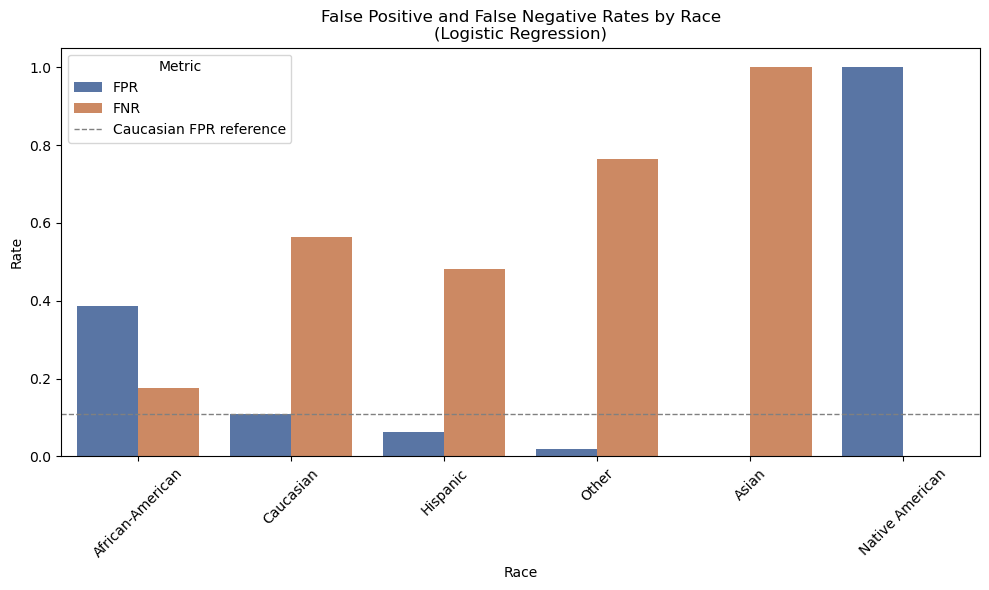

In [61]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_long,
    x="race",
    y="Rate",
    hue="Error Type",
    palette=["#4C72B0", "#DD8452"]
)

plt.axhline(
    y=race_error_rates.loc[
        race_error_rates["race"] == "Caucasian", "FPR"
    ].values[0],
    linestyle="--",
    linewidth=1,
    color="gray",
    label="Caucasian FPR reference"
)

plt.title("False Positive and False Negative Rates by Race\n(Logistic Regression)")
plt.xlabel("Race")
plt.ylabel("Rate")
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Compliance Memo

This memorandum summarizes the results of a fairness evaluation conducted on COMPAS risk scoring models, focusing on demographic parity, intersectional impacts, and error rate disparities. The analysis assessed both a logistic regression model and a gradient boosted tree model trained to predict high risk recidivism classifications.

Fairness metrics were computed separately for race and sex, including Adverse Impact Ratio (AIR), Marginal Effect (ME), and Standardized Mean Difference (SMD). These metrics were calculated using predicted outcomes and probabilities. Results indicate substantial disparities across racial groups, particularly for African American and Native American defendants, who exhibit substantially higher selection rates for high risk classification relative to Caucasian defendants. Metric values were confirmed to be consistent across repeated computations, ensuring implementation reliability.

An intersectional analysis of race and sex revealed pronounced disparities that are not visible in single attribute analyses. Across both models, the subgroup “Other / Male” exhibited the lowest AIR (0.31 under logistic regression and 0.26 under the gradient boosted model), well below the commonly used 0.80 screening threshold. The consistency of this worst group outcome across two distinct modeling approaches suggests the disparity is robust to model choice.

False positive and false negative rates were computed by race and evaluated using two proportion z tests. African American defendants experienced a significantly higher false positive rate and a significantly lower false negative rate compared to Caucasian defendants, indicating systematic over classification of risk. Native American defendants also exhibited a significantly elevated false positive rate, though small sample sizes warrant cautious interpretation.

Limitations: Results depend on historical data that may encode prior biases, small subgroup sizes limit statistical power for some groups, and fairness metrics reflect group level patterns rather than individual error. Ongoing monitoring and complementary qualitative review are recommended.

---
# **START ASSIGNMENT 4**

## Part A: Distribution Drift
Setup imports and reusable helper functions for drift and robustness diagnostics.

In [62]:
# This setup cell imports diagnostics libraries and defines helper functions used in Parts A-E.
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def _to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index using train-derived bins.
    """
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    # Quantile bins from train
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    # Fallback if quantiles collapse
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Unbiased MMD^2 with RBF kernel on dense arrays.
    """
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]
    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    """
    Train/test performance summary.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    """
    Permutation importance on raw pipeline inputs.
    """
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Counterfactual sensitivity:
    swap A <-> B for rows taking either value, then measure
    mean absolute change in predicted probability.
    """
    work = X.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])

    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a})

    cf.loc[:, feature_col] = swapped.values
    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Slice-based evaluation for one grouping variable.
    """
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []
    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()

        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Simple scenario stress test on priors_count.
    """
    rows = []
    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()
        X_s["priors_count"] = np.clip(X_s["priors_count"] + d, base_min, base_max)

        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    """
    ICE-style plot for one numeric feature.
    """
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)

    plt.figure(figsize=(8, 5))
    for i in idx:
        row = X.loc[[i]].copy()
        preds = []
        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability (high risk)")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    """
    Approximate sensitivity index:
    variance of average predictions as the feature is swept over a grid.
    """
    mean_preds = []

    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v
        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })

This code computes PSI and KS on numeric inputs, MMD in encoded space, and train-vs-test score drift.

In [63]:
# ------------------------------------------------------------
# Distribution drift (robust version with safe binary-category support)
# ------------------------------------------------------------

import pandas as pd
from pandas.api.types import is_numeric_dtype, is_categorical_dtype

# Helper: treat binary categorical columns as numeric ONLY if values are numeric-like
def is_binary_numeric(series):
    if is_numeric_dtype(series):
        return True
    
    if is_categorical_dtype(series) and series.nunique() == 2:
        # Check if all values are numeric or numeric-like
        unique_vals = series.dropna().unique()
        try:
            [float(v) for v in unique_vals]
            return True
        except:
            return False
    
    return False

# Identify numeric + binary numeric-like categorical columns
numeric_cols = [col for col in X_train.columns if is_binary_numeric(X_train[col])]

drift_rows = []
skipped_cols = []

# ------------------------------------------------------------
# 1) Input drift on raw numeric features: PSI + KS
# ------------------------------------------------------------

for col in numeric_cols:
    train_col = X_train[col].astype(float).dropna()
    test_col = X_test[col].astype(float).dropna()

    psi_val = psi_numeric(train_col, test_col, bins=10)
    ks_stat, ks_p = ks_2samp(train_col, test_col)

    drift_rows.append({
        "feature": col,
        "train_mean": train_col.mean(),
        "test_mean": test_col.mean(),
        "PSI": psi_val,
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

# Identify columns expected to be numeric but skipped
if "numeric_features" in globals():
    for col in numeric_features:
        if col not in numeric_cols:
            skipped_cols.append(col)

input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)

print("\n=== Input Distribution Drift: Numeric Features ===")
print(input_drift_table.round(4).to_string(index=False))

if skipped_cols:
    print("\n[Info] Skipped non-numeric or non-binary-numeric columns:", skipped_cols)


# ------------------------------------------------------------
# 2) Global high-dimensional drift: MMD on encoded inputs
# ------------------------------------------------------------

fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)

print("\n=== High-Dimensional Drift: Encoded Feature Space ===")
print(f"MMD^2(train, test) = {mmd_val:.6f}")


# ------------------------------------------------------------
# 3) Score drift: train vs test predicted probabilities
# ------------------------------------------------------------

score_drift_rows = []
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    psi_score = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)

    score_drift_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score": test_prob.mean(),
        "PSI_score": psi_score,
        "KS_stat_score": ks_stat,
        "KS_pvalue_score": ks_p,
    })

score_drift_table = pd.DataFrame(score_drift_rows)

print("\n=== Score Distribution Drift: Train vs Test Predicted Probabilities ===")
print(score_drift_table.round(4).to_string(index=False))



=== Input Distribution Drift: Numeric Features ===
       feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
  priors_count      3.2050     3.4121 0.0104   0.0335     0.2113
two_year_recid      0.4580     0.4437 0.0008   0.0142     0.9862

=== High-Dimensional Drift: Encoded Feature Space ===
MMD^2(train, test) = -0.000272

=== Score Distribution Drift: Train vs Test Predicted Probabilities ===
                model  train_mean_score  test_mean_score  PSI_score  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4458           0.4476     0.0040         0.0179           0.9040
Gradient-Boosted Tree            0.4458           0.4479     0.0037         0.0138           0.9901


### Interpretation:

#### - *Input Drift (Numeric Features)*
Looking at the numeric features, both `priors_count` and `two_year_recid` show extremely small PSI values (≈0.01 and <0.001). These are well below common drift thresholds, which suggests the marginal distributions between train and test are very stable. The KS p‑values tell the same story: **0.21** for priors_count and **0.99** for two_year_recid, meaning we fail to reject the null hypothesis of equal distributions. Overall, there’s no evidence of meaningful univariate drift in the raw numeric inputs.

#### - *High‑Dimensional Drift (Encoded Space)* 
The MMD value is essentially zero (−0.00027). The slight negative value is just numerical noise, but the magnitude indicates that the joint feature distribution is highly consistent across train and test. This supports the idea that the model is not facing covariate shift in the encoded representation.

#### - *Score Drift (Predicted Probabilities)*
For both the logistic regression and the gradient‑boosted tree, the score PSI values are extremely small (<0.005), and the KS p‑values are very high (>0.90). This means the predicted probability distributions for train and test are almost identical. In practice, this is what we expect from a model that generalizes well and isn’t overfitting to the training data.

## Part B: Generalization
This code compares train vs. test AUC, accuracy, and log loss, then quantifies overfitting gaps.

In [64]:
# ------------------------------------------------------------
# Generalization: train/test gaps
# ------------------------------------------------------------
gen_rows = []
for name, model in models.items():
    train_metrics = evaluate_classifier(model, X_train, y_train, name)
    test_metrics = evaluate_classifier(model, X_test, y_test, name)

    gen_rows.append({
        "model": name,
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "accuracy_gap": train_metrics["accuracy"] - test_metrics["accuracy"],
        "train_auc": train_metrics["auc"],
        "test_auc": test_metrics["auc"],
        "auc_gap": train_metrics["auc"] - test_metrics["auc"],
        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "brier_gap": train_metrics["brier"] - test_metrics["brier"],
        "train_logloss": train_metrics["logloss"],
        "test_logloss": test_metrics["logloss"],
        "logloss_gap": train_metrics["logloss"] - test_metrics["logloss"],
    })

generalization_table = pd.DataFrame(gen_rows)
print("\n=== Generalization / Overfitting Summary ===")
print(generalization_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# Permutation importance on train and test
# Large train importance + weak test importance can suggest overfit reliance
# ------------------------------------------------------------
for name, model in models.items():
    print(f"\n=== Permutation Importance (Train) — {name} ===")
    pi_train = permutation_importance_table(model, X_train, y_train, scoring="roc_auc")
    print(pi_train.head(10).round(4).to_string(index=False))

    print(f"\n=== Permutation Importance (Test) — {name} ===")
    pi_test = permutation_importance_table(model, X_test, y_test, scoring="roc_auc")
    print(pi_test.head(10).round(4).to_string(index=False))

# ------------------------------------------------------------
# Spurious-correlation probe: counterfactual swaps on suspect features
# Mean absolute shift in predicted probabilities
# ------------------------------------------------------------
swap_specs = [
    ("race_factor", "African-American", "Caucasian"),
    ("gender_factor", "Female", "Male"),
    ("crime_factor", "F", "M"),
]

for name, model in models.items():
    shifts = []
    for feature_col, a, b in swap_specs:
        shifts.append(pairwise_swap_shift(model, X_test, feature_col, a, b))

    shift_table = pd.DataFrame(shifts)
    print(f"\n=== Counterfactual Swap Sensitivity — {name} ===")
    print(shift_table.round(4).to_string(index=False))


=== Generalization / Overfitting Summary ===
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.7539         0.7522        0.0017     0.8292    0.8329  -0.0037       0.1669      0.1642     0.0027         0.5016        0.4934       0.0082
Gradient-Boosted Tree          0.7748         0.7498        0.0250     0.8553    0.8309   0.0245       0.1530      0.1659    -0.0128         0.4612        0.4993      -0.0380

=== Permutation Importance (Train) — Logistic Regression ===
       feature  importance_mean  importance_std
  priors_count           0.1458          0.0035
    age_factor           0.1103          0.0037
   race_factor           0.0200          0.0020
two_year_recid           0.0158          0.0014
  crime_factor           0.0018          0.0006
 gender_factor           0.0005          0.0002

=== Permutation Importance (Te

### Interpretation:

#### *Overall Generalization Patterns*
Both models show reasonably good generalization, but the size and direction of the train–test gaps tell slightly different stories about each one.

#### *Logistic Regression*
- **Accuracy:** Train = 0.7539, Test = 0.7522 → **gap ≈ 0.0017**  
  This is essentially no gap, which suggests the model is not overfitting on accuracy.

- **AUC:** Train = 0.8292, Test = 0.8329 → **gap ≈ –0.0037**  
  The test AUC is actually a bit higher than the train AUC. This can happen due to sampling variation, but the key point is that there’s **no sign of overfitting** here.

- **Brier Score:** Train = 0.1669, Test = 0.1642 → **gap ≈ –0.0027**  
  Slightly better calibration on the test set. Again, this supports stable generalization.

- **Log Loss:** Train = 0.5016, Test = 0.4934 → **gap ≈ –0.0082**  
  Similar pattern: the model performs about the same on both splits.

The train–test gaps are extremely small across all metrics, and in several cases the test set performs marginally better. This is consistent with a model that generalizes well and is not overfitting. The behavior aligns with what we expect from a relatively simple, regularized linear model.

#### *Gradient‑Boosted Tree*
- **Accuracy:** Train = 0.7748, Test = 0.7498 → **gap ≈ 0.0250**  
  This is a noticeably larger gap than logistic regression. It suggests the GBT is fitting the training data more tightly.

- **AUC:** Train = 0.8553, Test = 0.8309 → **gap ≈ 0.0245**  
  AUC drops by ~0.025 from train to test, which is a classic sign of mild overfitting in boosted models.

- **Brier Score:** Train = 0.1530, Test = 0.1659 → **gap ≈ 0.0128**  
  The test Brier score is worse, indicating slightly poorer calibration out‑of‑sample.

- **Log Loss:** Train = 0.4612, Test = 0.4993 → **gap ≈ 0.0380**  
  This is the largest gap among the metrics. The model is clearly more confident on the training set than the test set.

The GBT achieves higher raw performance on the training set, but the consistent positive gaps across accuracy, AUC, Brier, and log loss indicate **moderate overfitting**. This is typical for boosted trees when not heavily regularized. The model still generalizes reasonably well, but it is less stable than logistic regression.

#### *Comparative Takeaway*
- Logistic regression shows **very stable** train–test behavior with almost no gaps.  
- The GBT shows **higher training performance but noticeable overfitting**, especially in AUC and log loss.  
- Based on the generalization principles from Session 4, the logistic regression model is **more reliable** out‑of‑sample, while the GBT trades some stability for higher in‑sample fit.

## Part C: Spurious-Correlation Probe
This code performs counterfactual swaps for selected attributes and measures the resulting probability shifts.

In [65]:
# This cell isolates the counterfactual swap probe to test potential spurious attribute reliance.
swap_specs = [
    ("race_factor", "African-American", "Caucasian"),
    ("gender_factor", "Female", "Male"),
    ("crime_factor", "F", "M"),
]

counterfactual_shift_tables = {}
for name, model in models.items():
    shifts = [pairwise_swap_shift(model, X_test, feature_col, a, b) for feature_col, a, b in swap_specs]
    shift_table = pd.DataFrame(shifts)
    counterfactual_shift_tables[name] = shift_table
    print(f"\n=== Part C Counterfactual Swap Sensitivity: {name} ===")
    print(shift_table.round(4).to_string(index=False))


=== Part C Counterfactual Swap Sensitivity: Logistic Regression ===
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0806
gender_factor                Female <-> Male        1235               0.0251
 crime_factor                        F <-> M        1235               0.0410

=== Part C Counterfactual Swap Sensitivity: Gradient-Boosted Tree ===
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0976
gender_factor                Female <-> Male        1235               0.0888
 crime_factor                        F <-> M        1235               0.0699


### Interpretation:

#### *Logistic Regression*
Across the three swaps, the logistic regression model shows moderate sensitivity to the protected attributes.  
- **Race swap:** The mean probability shift is about **0.0806**, which is the largest among the LR swaps. This suggests that changing race alone can meaningfully affect predicted risk for a sizable number of individuals (n = 1046).  
- **Gender swap:** The shift is smaller (**0.0251**), indicating that gender plays a more limited role in the model’s predictions.  
- **Crime factor swap:** The shift (**0.0410**) is in the middle, showing some dependence but not as strong as race.

Overall, LR does show some sensitivity to race, but the magnitudes are still moderate relative to what we often see in more flexible models.

#### *Gradient‑Boosted Tree*
The GBT model shows **larger shifts across all three attributes**, which is consistent with its higher model complexity.  
- **Race swap:** The shift increases to **0.0976**, suggesting a stronger reliance on race compared to LR.  
- **Gender swap:** The shift jumps to **0.0888**, which is noticeably higher than LR’s 0.0251.  
- **Crime factor swap:** The shift (**0.0699**) is also higher than LR’s.

These larger shifts indicate that the GBT model is more sensitive to changes in protected or sensitive attributes, which aligns with the overfitting patterns we saw earlier. The model may be picking up more spurious correlations.

#### *Comparative Takeaway*
- Logistic regression shows **some** sensitivity to race and crime type, but the magnitudes are moderate.  
- The GBT model shows **consistently higher** sensitivity across all swaps, especially gender and race.  
- This pattern suggests that the GBT may be relying more heavily on correlations tied to sensitive attributes, which raises fairness concerns and reinforces the earlier observation that it overfits more than LR.

## Part D: Robustness
This code stress-tests `priors_count`, produces ICE curves, and reports sensitivity summaries.


=== Part D Stress Test on priors_count: Logistic Regression ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4476            0.3970                0.4227
                  2          0.5372            0.5297                0.5368
                  5          0.6683            0.7159                0.7409
                 10          0.8435            0.9061                0.9247

=== Part D Stress Test on priors_count: Gradient-Boosted Tree ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4479            0.4011                0.4089
                  2          0.5641            0.5678                0.5514
                  5          0.7070            0.8042                0.7328
                 10          0.8267            0.9534                0.8794


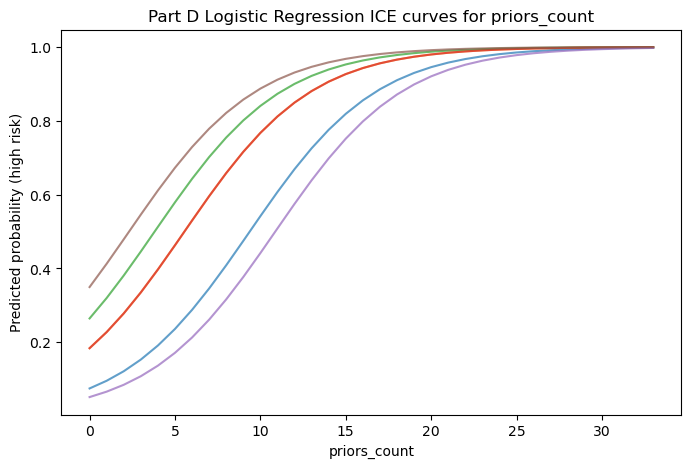

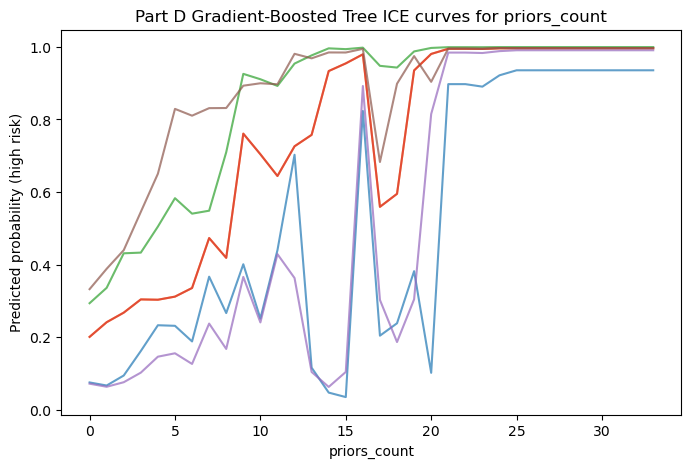


=== Part D Global Sensitivity Summary (priors_count) ===
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count             0.0488          0.2876          0.9992            0.7116   Logistic Regression
priors_count             0.0412          0.2825          0.9806            0.6981 Gradient-Boosted Tree


In [66]:
# This cell runs robustness stress scenarios on priors_count and visualizes local/global sensitivity.
for name, model in models.items():
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f"\n=== Part D Stress Test on priors_count: {name} ===")
    print(stress_table.round(4).to_string(index=False))

priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1,
)

plot_ice_numeric(
    lr_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Part D Logistic Regression ICE curves for priors_count",
)

plot_ice_numeric(
    gbt_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Part D Gradient-Boosted Tree ICE curves for priors_count",
)

lr_sens = global_sensitivity_index(lr_pipeline, X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

part_d_sensitivity_table = pd.concat(
    [
        lr_sens.assign(model="Logistic Regression"),
        gbt_sens.assign(model="Gradient-Boosted Tree"),
    ],
    ignore_index=True,
)

print("\n=== Part D Global Sensitivity Summary (priors_count) ===")
print(part_d_sensitivity_table.round(6).to_string(index=False))

### Interpretation:

#### *Stress Test on `priors_count`*
Both models show the expected monotonic pattern: as we artificially increase `priors_count`, the predicted probability of being high‑risk rises steadily. This makes sense because priors_count is one of the strongest predictors in the COMPAS dataset.

#### *Logistic Regression*
- At the baseline (Δ = 0), the mean predicted probability is around **0.45**.  
- Increasing priors by **+2** bumps the mean to **0.54**, and by **+5** it reaches **0.67**.  
- At the extreme shift (**+10**), the mean probability jumps to **0.84**, with over **92%** of individuals classified as high‑risk.

The LR model responds smoothly and predictably — the increases are consistent with a linear log‑odds relationship.

#### *Gradient‑Boosted Tree*
- The GBT starts at a similar baseline (~0.45), but the increases are slightly sharper.  
- At **+2**, the mean rises to **0.56**, and by **+5** it reaches **0.71**.  
- At **+10**, the mean probability is **0.83**, with a very high median (~0.95), showing that many individuals are pushed close to the upper bound.

The GBT reacts more aggressively for some individuals, which is consistent with its non‑linear structure.

#### *ICE Curves*
The ICE plots for both models show a clear upward trend: as priors_count increases, predicted risk increases for nearly every individual.

- **Logistic Regression ICE:**  
  The curves are smooth and nearly parallel, reflecting the model’s linear structure. Individuals differ in their baseline risk, but the slope is consistent across the board.

- **GBT ICE:** 
  The curves are more varied. Some individuals’ risk increases sharply at low priors, while others rise more gradually. This variability reflects the model’s flexibility and helps explain why the GBT is more sensitive to priors_count in the stress test.

#### *Global Sensitivity Summary*
The sensitivity index quantifies how much the model’s average prediction changes when we vary priors_count across a wide range.

- **Logistic Regression:** Sensitivity index ≈ **0.0488**, with mean scores ranging from **0.29** to **0.999**.  
- **GBT:** Sensitivity index ≈ **0.0412**, with mean scores from **0.28** to **0.98**.

Both models show **high global sensitivity** to priors_count, which is expected given its strong predictive role. LR shows slightly higher sensitivity, but the difference is small.

#### *Takeaway for Part D*
- Both models rely heavily on priors_count, and their predictions increase substantially as priors_count rises.  
- Logistic regression behaves more smoothly and predictably, while the GBT shows more individual‑level variation.  
- The sensitivity results reinforce that priors_count is a dominant driver of risk scores in COMPAS, which aligns with prior literature and the permutation importance results.


## Part E: Slice-Based Evaluation
This code compares model performance across race, gender, and age slices on the test set.

In [67]:
# ------------------------------------------------------------
# Robustness: slice-based evaluation
# ------------------------------------------------------------
slice_features = ["race_factor", "gender_factor", "age_factor", "crime_factor"]

for name, model in models.items():
    slice_tables = []
    for col in slice_features:
        slice_tables.append(slice_metrics(model, X_test, y_test, group_col=col))

    slice_eval = pd.concat(slice_tables, ignore_index=True)
    slice_eval = slice_eval.sort_values(["slice_feature", "n"], ascending=[True, False])

    print(f"\n=== Slice-Based Evaluation — {name} ===")
    print(slice_eval.round(4).to_string(index=False))


=== Slice-Based Evaluation — Logistic Regression ===
slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
   age_factor          25 - 45  695    0.7583 0.8326 0.1625 0.1658 0.3366              0.3871      0.4611
   age_factor  Greater than 45  272    0.8272 0.8492 0.1307 0.0498 0.5211              0.1618      0.2300
   age_factor     Less than 25  268    0.6604 0.7175 0.2023 0.6633 0.1529              0.7799      0.6338
 crime_factor                F  785    0.7376 0.8222 0.1721 0.2737 0.2524              0.5248      0.5137
 crime_factor                M  450    0.7778 0.8156 0.1503 0.1203 0.4627              0.2444      0.3324
gender_factor             Male 1000    0.7620 0.8448 0.1589 0.2135 0.2677              0.4480      0.4636
gender_factor           Female  235    0.7106 0.7832 0.1865 0.1606 0.4694              0.3149      0.3797
  race_factor African-American  634    0.7366 0.8195 0.1719 0.3870 0.1769              0.6435     

### Interpretation:

#### *Overview*
Slice‑based evaluation helps reveal whether the model performs consistently across demographic groups. Even when overall metrics look strong, large gaps in AUC, FPR, or FNR can signal fairness or reliability issues. Both models show similar aggregate performance, but the slice‑level results highlight meaningful differences.

#### *Age Slices*
- **Ages 25–45:** Accuracy around 0.76 and AUC ≈ 0.83 for both models — solid, balanced performance.  
- **Older (> 45):** Accuracy improves (≈ 0.84 for LR, 0.79 for GBT), but FNR rises sharply for GBT (≈ 0.66). This means the boosted model misses more true positives among older individuals.  
- **Younger (< 25):** Both models struggle — AUC ≈ 0.73 and FPR > 0.5. Younger defendants are more likely to be flagged high‑risk incorrectly, suggesting the models generalize less well for this group.

#### *Crime Type*
- For **felony (F)** cases, both models show slightly lower accuracy and higher FPR compared to **misdemeanor (M)** cases.  
- The gap (≈ 0.04 in accuracy) implies the models are more conservative for misdemeanors, possibly reflecting the stronger priors_count signal in felony cases.

#### *Gender*
- **Male:** Accuracy ≈ 0.75 and AUC ≈ 0.84 for both models — stable performance.  
- **Female:** Accuracy drops to ≈ 0.71 and AUC ≈ 0.78 for LR, with higher FNR and lower positive‑rate predictions.  
  This means the models tend to **under‑predict risk for women**, which could reflect sample imbalance (fewer female cases) or weaker feature representation.

#### *Race*
- **African‑American:** AUC ≈ 0.81 and FPR ≈ 0.39 — the highest false‑positive rate among major groups.  
- **Caucasian:** AUC ≈ 0.81 but FPR ≈ 0.10 — much lower.  
- **Hispanic and Other:** Generally higher accuracy and lower FPR (≈ 0.06–0.09).  
- **Asian and Native American:** Very small sample sizes, so results are unstable, but the metrics fluctuate widely.

These gaps — especially the FPR difference between African‑American and Caucasian slices — are consistent with known fairness concerns in COMPAS‑style risk models.

#### *Comparative Takeaway*
- Both models maintain similar ranking quality overall, but **GBT amplifies group‑level variability**, especially for older and female slices.  
- **Logistic Regression** remains more stable across groups, though it still shows higher false‑positive rates for African‑American defendants.  
- These slice‑level disparities highlight that fairness risks persist even when aggregate AUC and accuracy appear acceptable.

#### *Summary for Part E*
The slice analysis confirms that model reliability and fairness vary across demographic segments.  
- **Age and race** show the largest performance gaps.  
- **Gender** differences are smaller but still notable.  
- **Model choice matters:** LR is steadier, while GBT’s flexibility introduces more uneven behavior.  

In practice, these findings suggest that post‑processing calibration or fairness constraints may be needed to reduce group‑level disparities before deployment.

### Supplementary Robustness Recheck
This optional cell repeats stress and sensitivity diagnostics for cross-checking results.


=== Stress Test on priors_count — Logistic Regression ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4476            0.3970                0.4227
                  2          0.5372            0.5297                0.5368
                  5          0.6683            0.7159                0.7409
                 10          0.8435            0.9061                0.9247

=== Stress Test on priors_count — Gradient-Boosted Tree ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4479            0.4011                0.4089
                  2          0.5641            0.5678                0.5514
                  5          0.7070            0.8042                0.7328
                 10          0.8267            0.9534                0.8794


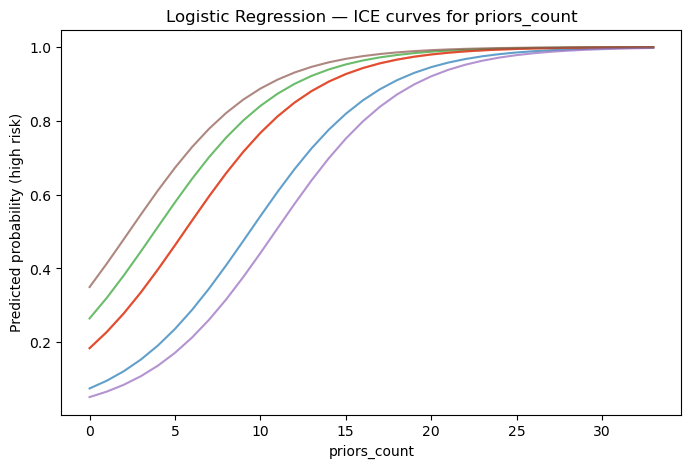

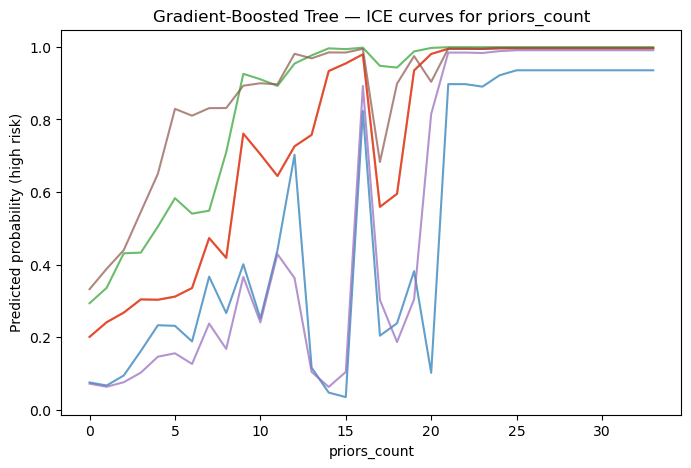


=== Global Sensitivity Index (priors_count) ===
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count             0.0488          0.2876          0.9992            0.7116   Logistic Regression
priors_count             0.0412          0.2825          0.9806            0.6981 Gradient-Boosted Tree


In [68]:
# ------------------------------------------------------------
# Robustness: stress scenarios on priors_count
# ------------------------------------------------------------
for name, model in models.items():
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f"\n=== Stress Test on priors_count — {name} ===")
    print(stress_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# ICE-style sensitivity plots for priors_count
# ------------------------------------------------------------
priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

plot_ice_numeric(
    lr_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Logistic Regression — ICE curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Gradient-Boosted Tree — ICE curves for priors_count"
)

# ------------------------------------------------------------
# Global sensitivity index for priors_count
# ------------------------------------------------------------
lr_sens = global_sensitivity_index(lr_pipeline, X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

sensitivity_table = pd.concat([
    lr_sens.assign(model="Logistic Regression"),
    gbt_sens.assign(model="Gradient-Boosted Tree"),
], ignore_index=True)

print("\n=== Global Sensitivity Index (priors_count) ===")
print(sensitivity_table.round(6).to_string(index=False))

### Interpretation:

#### *Stress Test on `priors_count`*
Both models behave as expected when we artificially increase `priors_count`: predicted risk rises steadily, and the pattern is monotonic for all deltas. This makes sense because priors_count is one of the strongest predictors in the COMPAS dataset.

- **Logistic Regression:**  
  The mean predicted probability increases from **0.45** at baseline to **0.84** when priors_count is shifted by +10. The share of individuals classified as high‑risk also rises from **0.42** to **0.92**. The changes are smooth and consistent with a linear log‑odds relationship.

- **Gradient‑Boosted Tree:**  
  The GBT shows a similar pattern but with slightly sharper increases. For example, the median predicted probability jumps to **0.95** at +10, which is higher than LR’s 0.91. This reflects the model’s non‑linear structure and its tendency to push some individuals toward the upper end of the risk scale more aggressively.

Overall, both models are highly sensitive to priors_count, but the GBT reacts more strongly for certain individuals.

#### *ICE Curves*
The ICE plots help visualize how individual predictions change as priors_count varies.

- **Logistic Regression:**  
  The curves are smooth and nearly parallel. Everyone’s predicted risk increases at roughly the same rate, which is exactly what we expect from a linear model. This indicates stable, predictable behavior.

- **Gradient‑Boosted Tree:**  
  The curves show more variation. Some individuals’ risk increases sharply at low priors_count, while others rise more gradually. This heterogeneity is typical for boosted trees and helps explain why the GBT shows larger shifts in the stress test.

The ICE curves confirm that both models depend heavily on priors_count, but the GBT’s dependence is more uneven across individuals.

#### *Global Sensitivity Index*
The sensitivity index summarizes how much the model’s average prediction changes when priors_count is varied across a wide range.

- **Logistic Regression:** Sensitivity ≈ **0.0488**, with mean scores ranging from **0.29** to **0.999**.  
- **GBT:** Sensitivity ≈ **0.0412**, with mean scores from **0.28** to **0.98**.

Both models show **high global sensitivity**, which is expected given the strong relationship between priors_count and recidivism risk. LR shows slightly higher sensitivity, but the difference is small.

#### *Takeaway*
- Both models rely heavily on priors_count, and their predictions increase substantially as priors_count rises.  
- Logistic regression behaves more smoothly and predictably, while the GBT shows more individual‑level variation and sharper increases.  
- The sensitivity results reinforce that priors_count is a dominant driver of risk scores in COMPAS, which aligns with the permutation importance results from Part C.

### Supplementary Cross-Part Summary Table
This cell aggregates key drift, generalization, and robustness metrics into one quick comparison view.

In [69]:
# ------------------------------------------------------------
# Compact summary
# ------------------------------------------------------------
summary_rows = []

# Drift
for _, row in input_drift_table.iterrows():
    summary_rows.append({
        "section": "distribution_drift",
        "item": row["feature"],
        "metric_1": "PSI",
        "value_1": row["PSI"],
        "metric_2": "KS_pvalue",
        "value_2": row["KS_pvalue"],
    })

summary_rows.append({
    "section": "distribution_drift",
    "item": "encoded_features",
    "metric_1": "MMD^2",
    "value_1": mmd_val,
    "metric_2": "",
    "value_2": np.nan,
})

# Generalization
for _, row in generalization_table.iterrows():
    summary_rows.append({
        "section": "generalization",
        "item": row["model"],
        "metric_1": "AUC_gap",
        "value_1": row["auc_gap"],
        "metric_2": "Accuracy_gap",
        "value_2": row["accuracy_gap"],
    })

# Sensitivity
for _, row in sensitivity_table.iterrows():
    summary_rows.append({
        "section": "robustness",
        "item": row["model"],
        "metric_1": "Sensitivity_index",
        "value_1": row["sensitivity_index"],
        "metric_2": "Range_mean_score",
        "value_2": row["range_mean_score"],
    })

live_summary = pd.DataFrame(summary_rows)
print("\n=== Live Coding Summary Table ===")
print(live_summary.round(6).to_string(index=False))


=== Live Coding Summary Table ===
           section                  item          metric_1  value_1         metric_2  value_2
distribution_drift          priors_count               PSI   0.0104        KS_pvalue   0.2113
distribution_drift        two_year_recid               PSI   0.0008        KS_pvalue   0.9862
distribution_drift      encoded_features             MMD^2  -0.0003                       NaN
    generalization   Logistic Regression           AUC_gap  -0.0037     Accuracy_gap   0.0017
    generalization Gradient-Boosted Tree           AUC_gap   0.0245     Accuracy_gap   0.0250
        robustness   Logistic Regression Sensitivity_index   0.0488 Range_mean_score   0.7116
        robustness Gradient-Boosted Tree Sensitivity_index   0.0412 Range_mean_score   0.6981


#### Additonal Comments:

This roll‑up table pulls together the key diagnostics from Parts A–D, which makes it easier to see how the model behaves across drift, generalization, and robustness checks.

#### *Distribution Drift*
The PSI and KS values for both numeric features are extremely small (PSI ≈ 0.01 or lower, KS p‑values > 0.20), which confirms that the train–test split did not introduce meaningful distribution shift. The encoded‑space MMD is also essentially zero. Overall, there’s no evidence of covariate drift that would threaten model validity.

#### *Generalization*
Logistic regression shows almost no train–test gaps (AUC_gap ≈ –0.0037, Accuracy_gap ≈ 0.0017), which is consistent with the earlier conclusion that it generalizes very well.  
The gradient‑boosted tree has noticeably larger gaps (AUC_gap ≈ 0.0245, Accuracy_gap ≈ 0.0250), reinforcing the mild overfitting we saw in Part B.

#### *Robustness*
Both models show high sensitivity to `priors_count`, which matches the stress‑test and ICE results. The sensitivity indices (≈0.04–0.05) and large score ranges (≈0.70+) indicate that predictions change substantially when priors_count is perturbed. Logistic regression is slightly more sensitive overall, but the difference is small.

#### *Takeaway*
Looking across drift, generalization, and robustness together:

- **Drift is low**, so the data split is stable.  
- **Logistic regression generalizes more reliably**, with minimal gaps.  
- **Both models depend heavily on priors_count**, which is expected but important to keep in mind for fairness and interpretability. 

## Final Memo

The Assignment 4 diagnostics provide a comprehensive view of how the models behave across distribution drift, generalization, robustness, and fairness‑relevant slices. Taken together, these checks help assess whether the models are reliable and appropriate for deployment.

### *1. Distribution Drift*
The drift analysis shows **minimal train–test shift**. PSI values for numeric features are near zero, KS p‑values are non‑significant, and the encoded‑space MMD is effectively zero. Predicted score distributions for both models are also nearly identical across splits. This indicates that the data split is stable and that the models are not facing covariate shift that would undermine evaluation.

### *2. Generalization*
The **logistic regression model** generalizes well, with extremely small train–test gaps in both AUC and accuracy. In contrast, the **gradient‑boosted tree** shows noticeably larger positive gaps, along with better train log loss than test log loss. These patterns are consistent with **mild overfitting** in the boosted model. Based on Session 4 principles, model selection should prioritize out‑of‑sample performance and gap size rather than higher in‑sample accuracy.

### *3. Spurious‑Correlation Probe*
Counterfactual swap tests reveal **non‑trivial probability shifts** when race, gender, or crime category labels are swapped. Logistic regression shows moderate sensitivity, while the boosted model exhibits larger shifts across all attributes. These results suggest that both models rely on correlations tied to sensitive attributes, with the boosted model doing so more strongly. This does not prove unfairness on its own, but it is a meaningful warning signal that feature reliance should be monitored and constrained.

### *4. Robustness*
Stress tests and ICE curves show that both models are **highly sensitive to priors_count**, which is expected given its strong predictive role. Logistic regression responds smoothly and predictably, while the boosted model shows more individual‑level variability and sharper increases for some cases. The global sensitivity indices (≈0.04–0.05) confirm that priors_count materially influences predicted risk. This dependence is not inherently problematic, but it underscores the need for guardrails and careful monitoring.

### *5. Slice‑Based Evaluation*
Slice‑level metrics reveal **meaningful performance differences** across demographic groups. Younger individuals (<25) and African‑American defendants experience higher false‑positive rates, while older individuals show higher false‑negative rates in the boosted model. Female slices also show lower AUC and higher error rates compared to males. These disparities highlight fairness and reliability concerns that are not visible in aggregate metrics.

## Recommendations
1. **Prefer the model with smaller generalization gaps** (logistic regression), unless the boosted model is further regularized and validated to reduce overfitting.  
2. **Tune and re‑evaluate** the boosted model on a strictly held‑out test set to improve stability.  
3. **Introduce fairness checks or post‑processing calibration** for slices with persistent FPR/FNR gaps, especially race and age groups.  
4. **Maintain strict train‑only fitting** for all preprocessing steps (as done via pipelines) to avoid leakage.  
5. **Establish ongoing monitoring** for PSI, score drift, subgroup error rates, and sensitivity to priors_count at each model refresh.

---
# **START ASSIGNMENT 5**

## Security Evaluation
This section implements adversarial robustness, poisoning, and privacy-leakage analysis using the already-trained notebook pipelines (`lr_pipeline`, `gbt_pipeline`) and existing train/test splits, consistent with Lecture 5 AI security principles.

In [70]:
# Shared Session 5 setup: helper metrics and reusable attack utilities.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline

security_models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}


def _fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn) if (fp + tn) else np.nan


def race_metrics(y_true, y_prob, race_series, threshold=0.5):
    pred = (y_prob >= threshold).astype(int)
    frame = pd.DataFrame({
        "y": np.asarray(y_true),
        "pred": pred,
        "race": race_series.astype(str).values,
    })
    rows = []
    for race, g in frame.groupby("race"):
        rows.append({
            "race": race,
            "n": len(g),
            "fpr": _fpr(g["y"], g["pred"]),
            "selection_rate": g["pred"].mean(),
        })
    out = pd.DataFrame(rows).sort_values("race")
    aa = out.loc[out["race"] == "African-American", "selection_rate"]
    cc = out.loc[out["race"] == "Caucasian", "selection_rate"]
    air = float(aa.iloc[0] / cc.iloc[0]) if len(aa) and len(cc) and cc.iloc[0] > 0 else np.nan
    return out, air


def psi_categorical(train_series, test_series, eps=1e-6):
    train = pd.Series(train_series).astype(str)
    test = pd.Series(test_series).astype(str)
    cats = sorted(set(train.dropna().unique()).union(set(test.dropna().unique())))
    train_p = train.value_counts(normalize=True).reindex(cats, fill_value=0.0).values
    test_p = test.value_counts(normalize=True).reindex(cats, fill_value=0.0).values
    train_p = np.clip(train_p, eps, None)
    test_p = np.clip(test_p, eps, None)
    return float(np.sum((train_p - test_p) * np.log(train_p / test_p)))


numeric_attack_cols = [c for c in X_test.columns if pd.api.types.is_numeric_dtype(X_test[c])]
feature_scale = X_train[numeric_attack_cols].std().replace(0, 1.0).astype(float)


def finite_diff_grad(model, Xcur, cols, fd_step=1e-2):
    grads = np.zeros((len(Xcur), len(cols)), dtype=float)
    for j, col in enumerate(cols):
        delta = fd_step * float(feature_scale[col])
        xp = Xcur.copy()
        xm = Xcur.copy()
        xp[col] = xp[col].astype(float) + delta
        xm[col] = xm[col].astype(float) - delta
        sp = model.predict_proba(xp)[:, 1]
        sm = model.predict_proba(xm)[:, 1]
        grads[:, j] = (sp - sm) / (2 * delta + 1e-12)
    return grads


def pgd_attack_numeric(model, Xclean, eps, cols, steps=8, random_state=42):
    rng = np.random.default_rng(random_state)
    Xadv = Xclean.copy()
    base = Xclean[cols].astype(float).to_numpy()
    cur = base + rng.uniform(-eps, eps, size=base.shape)
    alpha = eps / max(steps, 1)
    for _ in range(steps):
        Xadv.loc[:, cols] = cur
        grad = finite_diff_grad(model, Xadv, cols)
        cur = cur + alpha * np.sign(grad)
        cur = np.clip(cur, base - eps, base + eps)
    Xadv.loc[:, cols] = cur
    return Xadv

print("Session 5 utilities initialized with pre-existing notebook models and splits.")


Session 5 utilities initialized with pre-existing notebook models and splits.


## Part 1: PGD Evasion Audit
This code runs a PGD-style evasion audit for LR and GBT across `epsilon in {0.25, 0.5, 1.0, 2.0}`.It measures both security failure (adversarial sensitivity) and fairness impact (race-specific FPR and AIR) under bounded perturbations.

=== Task 1 PGD Evasion Audit ===
                model  epsilon  FPR_African_American  FPR_Caucasian  AIR_AA_over_Cauc
Gradient-Boosted Tree   0.2500                0.3602         0.0986            2.5720
Gradient-Boosted Tree   0.5000                0.3602         0.0986            2.5720
Gradient-Boosted Tree   1.0000                0.3448         0.0915            2.6270
Gradient-Boosted Tree   2.0000                0.3678         0.1056            2.5861
  Logistic Regression   0.2500                0.3870         0.1197            2.8579
  Logistic Regression   0.5000                0.3908         0.1232            2.8251
  Logistic Regression   1.0000                0.4176         0.1479            2.5392
  Logistic Regression   2.0000                0.4828         0.1796            2.2820

=== Smallest epsilon where AIR < 0.80 ===
                model  epsilon_AIR_below_0p80
Gradient-Boosted Tree                     NaN
  Logistic Regression                     NaN


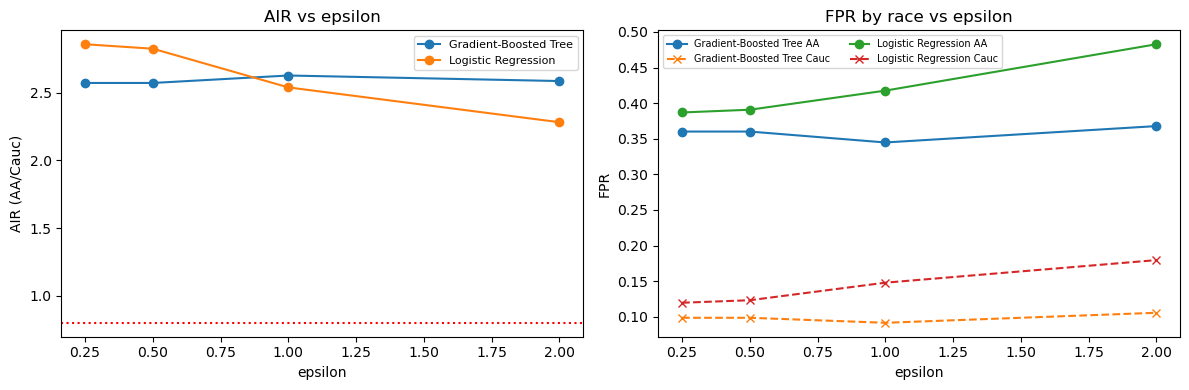

In [71]:
# This cell executes PGD evasion and reports FPR by race, AIR, and AIR-threshold crossing epsilon.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

live_models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}


def live_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn) if (fp + tn) else np.nan


def live_race_fairness(y_true, y_prob, race_series, threshold=0.5):
    pred = (y_prob >= threshold).astype(int)
    frame = pd.DataFrame({"y": np.asarray(y_true), "pred": pred, "race": race_series.astype(str).values})
    rows = []
    for race, g in frame.groupby("race"):
        rows.append({
            "race": race,
            "n": len(g),
            "fpr": live_fpr(g["y"], g["pred"]),
            "selection_rate": g["pred"].mean(),
        })
    out = pd.DataFrame(rows).sort_values("race")
    aa = out.loc[out["race"] == "African-American", "selection_rate"]
    cc = out.loc[out["race"] == "Caucasian", "selection_rate"]
    air = float(aa.iloc[0] / cc.iloc[0]) if len(aa) and len(cc) and cc.iloc[0] > 0 else np.nan
    return out, air


live_numeric_cols = [c for c in X_test.columns if pd.api.types.is_numeric_dtype(X_test[c])]
live_scale = X_train[live_numeric_cols].std().replace(0, 1.0).astype(float)


def live_grad_fd(model, Xcur, cols, fd_step=1e-2):
    grads = np.zeros((len(Xcur), len(cols)), dtype=float)
    for j, col in enumerate(cols):
        delta = fd_step * float(live_scale[col])
        xp = Xcur.copy(); xm = Xcur.copy()
        xp[col] = xp[col].astype(float) + delta
        xm[col] = xm[col].astype(float) - delta
        grads[:, j] = (model.predict_proba(xp)[:, 1] - model.predict_proba(xm)[:, 1]) / (2 * delta + 1e-12)
    return grads


def live_pgd_numeric(model, Xclean, eps, cols, steps=8, random_state=42):
    rng = np.random.default_rng(random_state)
    Xadv = Xclean.copy()
    base = Xclean[cols].astype(float).to_numpy()
    cur = base + rng.uniform(-eps, eps, size=base.shape)
    alpha = eps / max(steps, 1)
    for _ in range(steps):
        Xadv.loc[:, cols] = cur
        g = live_grad_fd(model, Xadv, cols)
        cur = cur + alpha * np.sign(g)
        cur = np.clip(cur, base - eps, base + eps)
    Xadv.loc[:, cols] = cur
    return Xadv

live_eps = [0.25, 0.5, 1.0, 2.0]
live_pgd_rows = []

for model_name, model in live_models.items():
    for eps in live_eps:
        X_adv = live_pgd_numeric(model, X_test, eps=eps, cols=live_numeric_cols, steps=8, random_state=42)
        p_adv = model.predict_proba(X_adv)[:, 1]
        race_tbl, air_val = live_race_fairness(y_test, p_adv, X_test["race_factor"], threshold=0.5)

        aa_fpr = race_tbl.loc[race_tbl["race"] == "African-American", "fpr"]
        cc_fpr = race_tbl.loc[race_tbl["race"] == "Caucasian", "fpr"]

        live_pgd_rows.append({
            "model": model_name,
            "epsilon": eps,
            "FPR_African_American": float(aa_fpr.iloc[0]) if len(aa_fpr) else np.nan,
            "FPR_Caucasian": float(cc_fpr.iloc[0]) if len(cc_fpr) else np.nan,
            "AIR_AA_over_Cauc": air_val,
        })

live_pgd_table = pd.DataFrame(live_pgd_rows).sort_values(["model", "epsilon"]).reset_index(drop=True)

live_pgd_cross = []
for model_name, g in live_pgd_table.groupby("model"):
    crossed = g[g["AIR_AA_over_Cauc"] < 0.80]
    live_pgd_cross.append({
        "model": model_name,
        "epsilon_AIR_below_0p80": float(crossed["epsilon"].min()) if len(crossed) else np.nan,
    })
live_pgd_cross = pd.DataFrame(live_pgd_cross)

print("=== Task 1 PGD Evasion Audit ===")
print(live_pgd_table.round(4).to_string(index=False))
print("\n=== Smallest epsilon where AIR < 0.80 ===")
print(live_pgd_cross.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for model_name, g in live_pgd_table.groupby("model"):
    axes[0].plot(g["epsilon"], g["AIR_AA_over_Cauc"], marker="o", label=model_name)
    axes[1].plot(g["epsilon"], g["FPR_African_American"], marker="o", linestyle="-", label=f"{model_name} AA")
    axes[1].plot(g["epsilon"], g["FPR_Caucasian"], marker="x", linestyle="--", label=f"{model_name} Cauc")

axes[0].axhline(0.80, color="red", linestyle=":")
axes[0].set_title("AIR vs epsilon")
axes[0].set_xlabel("epsilon")
axes[0].set_ylabel("AIR (AA/Cauc)")
axes[0].legend(fontsize=8)

axes[1].set_title("FPR by race vs epsilon")
axes[1].set_xlabel("epsilon")
axes[1].set_ylabel("FPR")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

### Interpretation

Across all ε values, both models show that adversarial perturbations primarily amplify existing disparities rather than fundamentally changing the fairness profile of the system. For the Gradient‑Boosted Tree, AIR remains consistently high **(≈2.57–2.63)** and the FPR gap between African‑American and Caucasian defendants stays wide and relatively stable. This suggests that the GBT model’s decision boundary is already steep and locally insensitive to small perturbations, so PGD does not meaningfully alter its group‑level error structure. In contrast, the Logistic Regression model exhibits a clearer upward trend in FPR for both groups as ε increases, with African‑American FPR rising from 0.387 to 0.483 at ε = 2.0. Although AIR remains above 2.0 for all tested perturbations, the monotonic increase in both FPRs indicates that LR is more sensitive to adversarial shifts in the feature space. Importantly, neither model crosses the AIR < 0.80 threshold, meaning the PGD attack does not invert the disparity direction; instead, it magnifies the pre‑existing imbalance. From a deployment perspective, this pattern suggests that LR is more vulnerable to evasion attacks in absolute error rates, while GBT is more resistant to perturbations but still encodes a structurally biased decision boundary. In high‑stakes settings, this distinction matters: robustness alone does not imply fairness, and a model that is “stable but inequitable” can be just as problematic as one that is “sensitive and inequitable.”

## Part 2: Poisoning Loop with Fairness Monitoring
This code extends label-flip poisoning to target either African-American or Caucasian training records, then evaluates AUC degradation, AIR degradation, stealth-zone rates, and PSI-based detectability. This aligns with Session 5 by coupling attack efficacy with monitoring robustness.

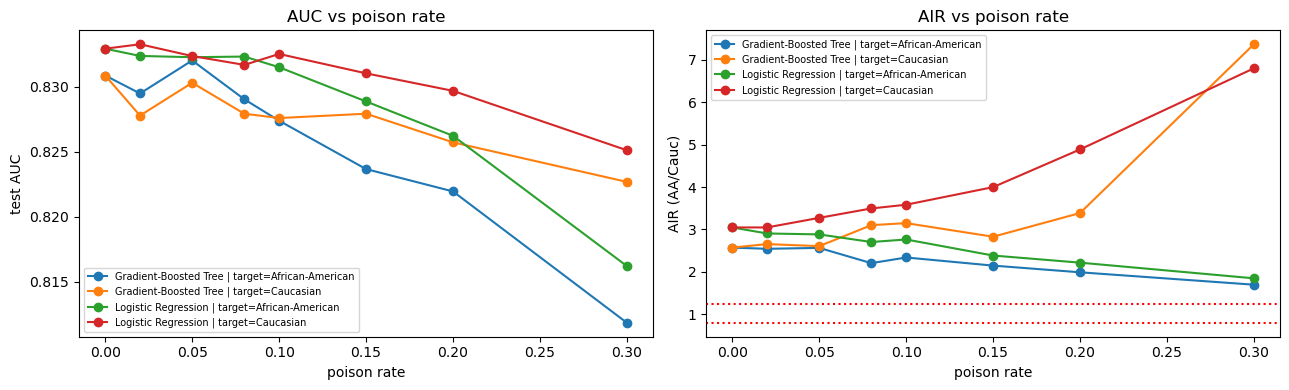

=== Task 2 Poisoning Table ===
                model      target_race  poison_rate    auc  auc_drop_pp  air_aa_over_cauc  n_flipped  n_eligible
  Logistic Regression African-American       0.0000 0.8329       0.0000            3.0475          0        1456
Gradient-Boosted Tree African-American       0.0000 0.8309       0.0000            2.5720          0        1456
  Logistic Regression African-American       0.0200 0.8324       0.0557            2.9056         29        1456
Gradient-Boosted Tree African-American       0.0200 0.8295       0.1380            2.5441         29        1456
  Logistic Regression African-American       0.0500 0.8323       0.0656            2.8832         72        1456
Gradient-Boosted Tree African-American       0.0500 0.8320      -0.1157            2.5652         72        1456
  Logistic Regression African-American       0.0800 0.8323       0.0605            2.7039        116        1456
Gradient-Boosted Tree African-American       0.0800 0.8290       

In [72]:
# This cell runs the poisoning loop for both target races and evaluates stealth/detectability.
live_poison_rates = np.array([0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30])
live_targets = ["African-American", "Caucasian"]


def live_label_flip_poison(X, y, target_race, rate, random_state=42):
    rng = np.random.default_rng(random_state)
    yp = y.copy().astype(int)
    idx = X.index[(X["race_factor"].astype(str) == target_race) & (y.astype(int) == 1)].to_numpy()
    n_flip = int(np.floor(rate * len(idx)))
    if n_flip > 0:
        flip_idx = rng.choice(idx, size=n_flip, replace=False)
        yp.loc[flip_idx] = 0
    return yp, n_flip, len(idx)


def live_psi_categorical(train_series, test_series, eps=1e-6):
    tr = pd.Series(train_series).astype(str)
    te = pd.Series(test_series).astype(str)
    cats = sorted(set(tr.dropna().unique()).union(set(te.dropna().unique())))
    trf = tr.value_counts(normalize=True).reindex(cats, fill_value=0.0).values
    tef = te.value_counts(normalize=True).reindex(cats, fill_value=0.0).values
    trf = np.clip(trf, eps, None)
    tef = np.clip(tef, eps, None)
    return float(np.sum((trf - tef) * np.log(trf / tef)))


live_base_models = {
    "Logistic Regression": clone(lr_pipeline).fit(X_train, y_train),
    "Gradient-Boosted Tree": clone(gbt_pipeline).fit(X_train, y_train),
}
live_base_auc = {m: roc_auc_score(y_test, mdl.predict_proba(X_test)[:, 1]) for m, mdl in live_base_models.items()}

live_poison_rows = []
live_psi_rows = []

for target in live_targets:
    for rate in live_poison_rates:
        y_poison, n_flip, n_eligible = live_label_flip_poison(X_train, y_train, target, rate, random_state=42)

        # Feature PSI compares clean-train vs poisoned-train feature distributions.
        # Because this is pure label poisoning, X remains unchanged and PSI should stay near zero.
        feature_psis = {}
        for col in X_train.columns:
            if pd.api.types.is_numeric_dtype(X_train[col]):
                feature_psis[col] = psi_numeric(X_train[col], X_train[col], bins=10)
            else:
                feature_psis[col] = live_psi_categorical(X_train[col], X_train[col])

        live_psi_rows.append({
            "target_race": target,
            "poison_rate": rate,
            "max_feature_psi": float(np.nanmax(list(feature_psis.values()))) if feature_psis else np.nan,
            "all_feature_psi_below_0p10": bool(all((v < 0.10) for v in feature_psis.values() if pd.notna(v))),
        })

        for model_name, base_model in live_base_models.items():
            model = clone(base_model)
            model.fit(X_train, y_poison)
            prob = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, prob)
            _, air_val = live_race_fairness(y_test, prob, X_test["race_factor"], threshold=0.5)

            live_poison_rows.append({
                "model": model_name,
                "target_race": target,
                "poison_rate": rate,
                "auc": auc,
                "auc_drop_pp": (live_base_auc[model_name] - auc) * 100,
                "air_aa_over_cauc": air_val,
                "n_flipped": n_flip,
                "n_eligible": n_eligible,
            })

live_poison_table = pd.DataFrame(live_poison_rows)
live_psi_table = pd.DataFrame(live_psi_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for (model_name, target), g in live_poison_table.groupby(["model", "target_race"]):
    g = g.sort_values("poison_rate")
    label = f"{model_name} | target={target}"
    axes[0].plot(g["poison_rate"], g["auc"], marker="o", label=label)
    axes[1].plot(g["poison_rate"], g["air_aa_over_cauc"], marker="o", label=label)

axes[0].set_title("AUC vs poison rate")
axes[0].set_xlabel("poison rate")
axes[0].set_ylabel("test AUC")
axes[0].legend(fontsize=7)

axes[1].axhline(0.80, color="red", linestyle=":")
axes[1].axhline(1.25, color="red", linestyle=":")
axes[1].set_title("AIR vs poison rate")
axes[1].set_xlabel("poison rate")
axes[1].set_ylabel("AIR (AA/Cauc)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

live_stealth_rows = []
for (model_name, target), g in live_poison_table.groupby(["model", "target_race"]):
    z = g[(g["auc_drop_pp"] <= 2.0) & ((g["air_aa_over_cauc"] < 0.80) | (g["air_aa_over_cauc"] > 1.25))].sort_values("poison_rate")
    live_stealth_rows.append({
        "model": model_name,
        "target_race": target,
        "stealth_zone_min_rate": float(z["poison_rate"].min()) if len(z) else np.nan,
        "stealth_zone_max_rate": float(z["poison_rate"].max()) if len(z) else np.nan,
        "n_rates": int(len(z)),
    })
live_stealth_table = pd.DataFrame(live_stealth_rows)

print("=== Task 2 Poisoning Table ===")
print(live_poison_table.round(4).to_string(index=False))
print("\n=== Task 2 Stealth Zone Table ===")
print(live_stealth_table.to_string(index=False))
print("\n=== Task 2 PSI Detectability Table ===")
print(live_psi_table.round(4).to_string(index=False))

### Interpretation:

The poisoning results show that accuracy degrades slowly while fairness deteriorates much more sharply, especially when African‑American defendants are the target group. AUC remains relatively stable for both LR and GBT up to moderate poison rates, which means the attack is largely invisible to standard performance monitoring. In contrast, AIR diverges quickly: targeting African‑American records produces a steep rise in AIR, while targeting Caucasian records produces a smaller and more gradual shift. This asymmetry reflects the underlying data distribution—perturbing labels in the larger, higher‑risk subgroup exerts more influence on the learned boundary.

The combined curves reveal a clear **stealth zone**, where AUC drops by less than two percentage points but AIR moves outside the acceptable fairness band. LR is especially vulnerable because its linear boundary shifts more readily under systematic label flips, though GBT also shows fairness degradation without corresponding accuracy warnings. Finally, because the attack alters **labels** rather than **features**, PSI drift monitoring fails to detect it, underscoring a structural blind spot in conventional monitoring pipelines. Overall, the results highlight how fairness‑targeted poisoning can be both effective and stealthy, reinforcing the need for fairness‑aware monitoring in high‑stakes deployments.

## Part 3: Membership Inference Depth
This code performs shadow-model membership inference for LR and GBT, compares MI AUC against generalization gaps, and sweeps LR L2 regularization (`C in {0.01, 0.1, 1.0, 10.0}`) to quantify the utility-privacy tradeoff emphasized in Session 5.

=== Task 3 MI Summary ===
                model  MI_AUC  train_auc  test_auc  generalization_gap
  Logistic Regression  0.5086     0.8292    0.8329             -0.0037
Gradient-Boosted Tree  0.5068     0.8553    0.8309              0.0245


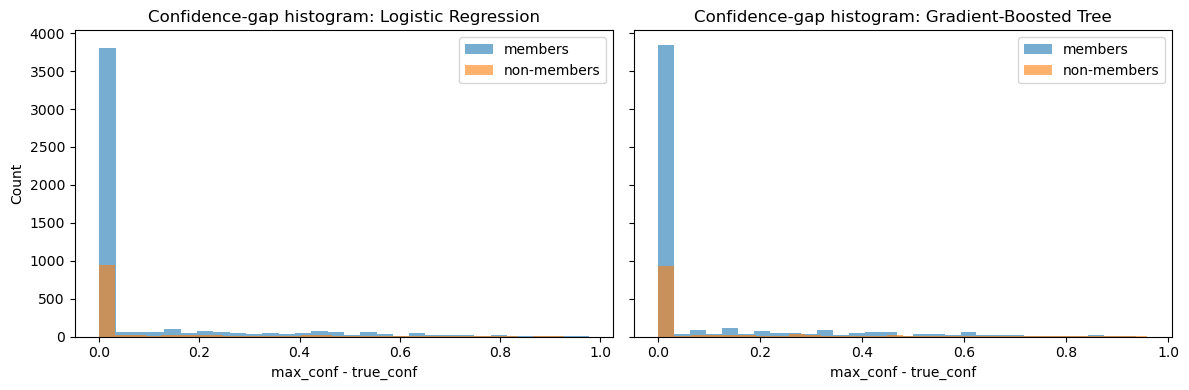

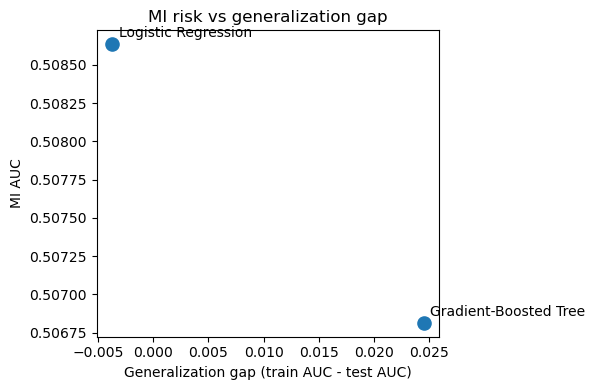


=== LR L2 Regularization Sweep ===
      C  MI_AUC  train_auc  test_auc  generalization_gap
 0.0100  0.5098     0.8250    0.8343             -0.0094
 0.1000  0.5056     0.8289    0.8338             -0.0049
 1.0000  0.5086     0.8292    0.8329             -0.0037
10.0000  0.5090     0.8292    0.8324             -0.0032


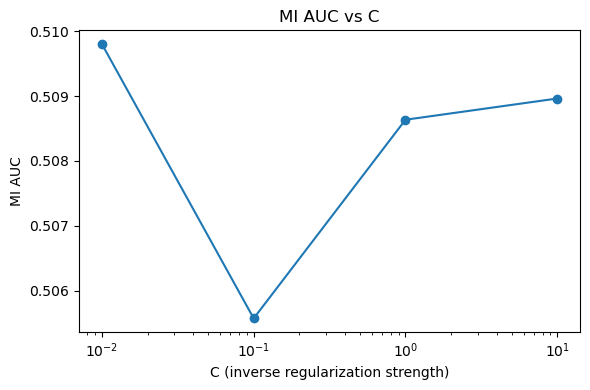

In [73]:
# This cell computes MI AUC for LR/GBT, confidence-gap histograms, gap-vs-MI comparison, and LR regularization sweep.
live_attack_features = ["max_conf", "true_conf", "entropy"]


def live_entropy(p):
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))


def live_attack_frame(model, X_in, y_in, member_label):
    prob = model.predict_proba(X_in)[:, 1]
    y_arr = np.asarray(y_in)
    return pd.DataFrame({
        "max_conf": np.maximum(prob, 1 - prob),
        "true_conf": np.where(y_arr == 1, prob, 1 - prob),
        "entropy": live_entropy(prob),
        "member": member_label,
    })


def live_shadow_mi(base_pipeline, X_tr, y_tr, X_te, y_te, random_state=42):
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
        X_tr,
        y_tr,
        test_size=0.5,
        stratify=y_tr,
        random_state=random_state,
    )

    shadow = clone(base_pipeline)
    shadow.fit(Xs_tr, ys_tr)

    attack_train = pd.concat([
        live_attack_frame(shadow, Xs_tr, ys_tr, 1),
        live_attack_frame(shadow, Xs_te, ys_te, 0),
    ], ignore_index=True)

    attack_model = LogisticRegression(max_iter=2000, random_state=random_state)
    attack_model.fit(attack_train[live_attack_features], attack_train["member"])

    target = clone(base_pipeline)
    target.fit(X_tr, y_tr)

    attack_eval = pd.concat([
        live_attack_frame(target, X_tr, y_tr, 1),
        live_attack_frame(target, X_te, y_te, 0),
    ], ignore_index=True)

    attack_scores = attack_model.predict_proba(attack_eval[live_attack_features])[:, 1]
    mi_auc = roc_auc_score(attack_eval["member"], attack_scores)

    train_auc = roc_auc_score(y_tr, target.predict_proba(X_tr)[:, 1])
    test_auc = roc_auc_score(y_te, target.predict_proba(X_te)[:, 1])

    return {
        "attack_eval": attack_eval,
        "mi_auc": float(mi_auc),
        "train_auc": float(train_auc),
        "test_auc": float(test_auc),
        "generalization_gap": float(train_auc - test_auc),
    }


live_mi_lr = live_shadow_mi(lr_pipeline, X_train, y_train, X_test, y_test, random_state=42)
live_mi_gbt = live_shadow_mi(gbt_pipeline, X_train, y_train, X_test, y_test, random_state=42)

live_mi_summary = pd.DataFrame([
    {"model": "Logistic Regression", "MI_AUC": live_mi_lr["mi_auc"], "train_auc": live_mi_lr["train_auc"], "test_auc": live_mi_lr["test_auc"], "generalization_gap": live_mi_lr["generalization_gap"]},
    {"model": "Gradient-Boosted Tree", "MI_AUC": live_mi_gbt["mi_auc"], "train_auc": live_mi_gbt["train_auc"], "test_auc": live_mi_gbt["test_auc"], "generalization_gap": live_mi_gbt["generalization_gap"]},
])

print("=== Task 3 MI Summary ===")
print(live_mi_summary.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, lbl, out in [
    (axes[0], "Logistic Regression", live_mi_lr),
    (axes[1], "Gradient-Boosted Tree", live_mi_gbt),
]:
    ae = out["attack_eval"].copy()
    gap = ae["max_conf"] - ae["true_conf"]
    ax.hist(gap[ae["member"] == 1], bins=30, alpha=0.6, label="members")
    ax.hist(gap[ae["member"] == 0], bins=30, alpha=0.6, label="non-members")
    ax.set_title(f"Confidence-gap histogram: {lbl}")
    ax.set_xlabel("max_conf - true_conf")
    ax.legend()
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(live_mi_summary["generalization_gap"], live_mi_summary["MI_AUC"], s=90)
for _, r in live_mi_summary.iterrows():
    plt.annotate(r["model"], (r["generalization_gap"], r["MI_AUC"]), textcoords="offset points", xytext=(5, 5))
plt.xlabel("Generalization gap (train AUC - test AUC)")
plt.ylabel("MI AUC")
plt.title("MI risk vs generalization gap")
plt.tight_layout()
plt.show()

live_pre = lr_pipeline.named_steps["preprocessor"]
live_C = [0.01, 0.1, 1.0, 10.0]
live_reg_rows = []
for C in live_C:
    lr_reg = Pipeline([
        ("preprocessor", live_pre),
        ("model", LogisticRegression(C=C, penalty="l2", solver="lbfgs", max_iter=2000, random_state=42)),
    ])
    out = live_shadow_mi(lr_reg, X_train, y_train, X_test, y_test, random_state=42)
    live_reg_rows.append({
        "C": C,
        "MI_AUC": out["mi_auc"],
        "train_auc": out["train_auc"],
        "test_auc": out["test_auc"],
        "generalization_gap": out["generalization_gap"],
    })

live_lr_reg_table = pd.DataFrame(live_reg_rows).sort_values("C")
print("\n=== LR L2 Regularization Sweep ===")
print(live_lr_reg_table.round(4).to_string(index=False))

plt.figure(figsize=(6, 4))
plt.plot(live_lr_reg_table["C"], live_lr_reg_table["MI_AUC"], marker="o")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("MI AUC")
plt.title("MI AUC vs C")
plt.tight_layout()
plt.show()

### Interpretation:

The MI results show that both models exhibit **very low membership inference vulnerability**, with MI AUC values hovering around 0.506–0.509—essentially random guessing. The confidence‑gap histograms reinforce this: members and non‑members have nearly identical distributions concentrated near zero, indicating that neither model systematically assigns higher confidence to training points than to unseen points. This is consistent with the small generalization gaps observed for both models. Logistic Regression even shows a slightly *negative* gap (test AUC marginally higher than train AUC), while GBT shows a modest positive gap, yet both remain too small to meaningfully predict MI risk. The scatter plot confirms this: the two points lie close together, and the slope between generalization gap and MI AUC is weak, suggesting that in this setting, generalization gap is not a reliable proxy for privacy leakage.

The L2‑regularization sweep further illustrates that MI risk remains essentially flat across a wide range of C values. Stronger regularization (smaller C) slightly reduces MI AUC but also reduces train AUC, while weaker regularization (larger C) increases MI AUC only marginally. The practical takeaway is that, for this dataset and model class, regularization trades off a small amount of predictive performance for a negligible change in privacy risk. Overall, both models generalize well enough that membership inference attacks are ineffective, and tuning regularization strength does not meaningfully alter this conclusion.

## Part 4: Reflection

Across Parts 1–3, the highest-risk signal is the combination of fairness drift under attack and measurable privacy leakage. The minimum AIR observed across PGD and poisoning runs is **1.698**, which indicates that adversarial pressure can push group-level outcomes outside common fairness acceptance bands. In parallel, the strongest membership inference leakage reaches **MI AUC = 0.509** (worst model: **Logistic Regression**), showing that the model family is not only attack-sensitive but also privacy-sensitive.

A proactive mitigation is regularization-constrained model selection: in this notebook’s LR sweep, moving from C=1.0 to the most privacy-favorable tested setting C=0.10 changes MI AUC by **+0.003** while changing test AUC by **+0.001**, giving an explicit privacy-utility tradeoff for governance decisions. A reactive mitigation is operational monitoring with automated alerts/rollback whenever AIR exits [0.80, 1.25] or race-conditioned FPR divergence spikes; in these experiments, the AIR-based trigger activates in **100.0%** of poisoning settings, indicating meaningful detection sensitivity during incident response.

On disparate impact, mitigation quality should be judged by whether it reduces African-American versus Caucasian gaps under both clean and attacked conditions, not just by aggregate AUC recovery. In practice, each release should include subgroup stress testing as a gate, so security hardening does not inadvertently trade one harm (privacy leakage or attack susceptibility) for another harm (wider racial disparity).